# Foundation models for time series: forecasting without fitting

Over the last three episodes we built an entire neural forecasting toolchain by hand:
recurrent networks that read a series step by step, transfer learning that moves
knowledge between related series, and transformers that attend to patches and variates.
Every one of those models shared an unspoken assumption — *you train it yourself, on
your own data, for your own task*. One dataset, one model, one training run. That is how
time series forecasting has worked for fifty years, from ARIMA to PatchTST.

This episode examines the idea that this assumption is now optional. **Time series
foundation models (TSFMs)** are large networks pre-trained once, by someone else, on
billions to trillions of time points scraped from wildly unrelated domains — web
traffic, electricity load, weather, retail, synthetic sine-and-noise cocktails. The bet
behind them is that time series, like language, has a *universal grammar*: trends,
seasonalities, mean reversion, and noise textures recur across domains, so a model that
has seen a million weekly rhythms can recognise the weekly rhythm in a series it has
never met — and forecast it with **zero training**. You download weights, hand the model
your raw history, and get a full probabilistic forecast back in milliseconds.

That is a strong claim, and this notebook treats it as a claim, not a fact. The plan:

1. Set up the usual arena — real daily retail sales, chronological splits, honest baselines.
2. Train our own *specialist* models (a linear network and a GRU, in Keras on the
   PyTorch/MPS backend) the old-fashioned way, so the newcomers have something to beat.
3. Open the hood: how do you feed a continuous series into a transformer at all?
   We rebuild the two dominant answers — **patching** and **quantization** — in a few
   lines of NumPy.
4. Climb the zero-shot ladder through three genuinely different architectures:
   **TimesFM 2.5** (Google, a patched decoder), **TiRex** (NX-AI, an xLSTM — no attention
   at all), and **Chronos-2** (Amazon, a universal multivariate forecaster with
   in-context learning).
5. Run a 120-forecast head-to-head, including probabilistic scoring — foundation models
   promise calibrated uncertainty, so we check calibration, not just point error.
6. Stress-test the headline use case: **cold start** — forecasting a series with only 60
   days of history.
7. Close with the uncomfortable part: the evaluation crisis, data leakage, and when a
   fifty-year-old baseline still wins.

# Setup

In [1]:
# Standard library imports
import os
import time
import warnings

# The Keras backend must be chosen BEFORE keras is imported
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Third-party imports: modeling
import torch
import keras

# Third-party imports: the foundation models
import timesfm
from tirex import load_model as load_tirex
from chronos import BaseChronosPipeline

# Configuration & Settings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())

Keras version: 3.15.0
Keras backend: torch


The import cell has one line that must come first and three imports you have not seen in
this series before.

The line that must come first: `os.environ['KERAS_BACKEND'] = 'torch'`. Keras 3 is a
frontend that can run on TensorFlow, JAX, or PyTorch, and it reads this environment
variable **once, at import time**. We set it to `'torch'` before `import keras` so that
every Keras tensor in this notebook is secretly a PyTorch tensor. This matters for a
practical reason: the foundation models we are about to download are all published as
PyTorch checkpoints, and PyTorch is also the stack with mature support for Apple's
**MPS** (Metal Performance Shaders) backend — the GPU inside this MacBook. One backend,
one device, everything on it: our hand-trained Keras models and the downloaded
foundation models will share the same GPU.

The three newcomers are the stars of the episode. `timesfm` is Google Research's
library for **TimesFM 2.5**; `tirex` ships NX-AI's **TiRex** (we alias its generic
`load_model` to `load_tirex` so the name says what it does); and `chronos` provides
Amazon's **Chronos** family through a single entry point, `BaseChronosPipeline`, which
inspects a checkpoint and returns the right pipeline class for it. None of these
require a GPU cluster or an API key — every model in this notebook is open-weights and
downloads from Hugging Face on first use, exactly like a pretrained vision or language
model would.

Finally, the two `warnings` calls silence the future-deprecation chatter that large
libraries emit on import; in a teaching notebook that noise would drown the outputs we
actually care about.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    STORE = 1                          # the store whose items we forecast
    HERO_ITEM = 1                      # the single series used for close-ups
    ARENA_ITEMS = list(range(1, 11))   # ten series for the head-to-head
    HORIZON = 14                       # forecast two weeks ahead
    LOOKBACK = 84                      # window length for models we train ourselves
    CONTEXT = 512                      # history handed to the foundation models
    N_ORIGINS = 12                     # weekly walk-forward test origins
    QUANTILES = [0.1, 0.5, 0.9]        # quantile levels for probabilistic scoring

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

# hardware: Apple GPU if present, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print("Computing on:", DEVICE)

Computing on: mps


The `CFG` class is our usual single home for every knob, so no magic numbers appear
inline later. The forecasting task is pinned down by three of them: every forecaster
must predict `HORIZON = 14` days (two weeks) of daily sales, evaluated at `N_ORIGINS =
12` weekly walk-forward origins, for the ten series in `ARENA_ITEMS`. `HERO_ITEM` is
the one series we will plot up close whenever a table of numbers would be too dry.

Two lengths deserve a careful look because they encode the asymmetry of this episode.
`LOOKBACK = 84` days is the input window for the models *we* train — the same twelve
weeks the transformer episode used. `CONTEXT = 512` days is what we hand the foundation
models. That is not an unfair advantage so much as a design difference: a model trained
from scratch must learn what to do with its input from that same small dataset, so
longer windows mean more parameters and more overfitting risk. A foundation model's
weights are already trained and frozen; more context is simply more information, at
zero training cost. (TimesFM 2.5 accepts up to 16,384 points; we stay at 512 to keep
every model on an identical diet.)

`QUANTILES` fixes the probabilistic vocabulary of the episode: we will ask each
foundation model for its 10th, 50th, and 90th percentile forecasts, giving a *median*
point forecast plus an *80% prediction interval* whose calibration we can check.

The last line picks the hardware. `torch.backends.mps.is_available()` is True on Apple
Silicon Macs, where PyTorch — and therefore Keras, and therefore every model in this
notebook — runs on the machine's own GPU. `np.random.seed(CFG.SEED)` pins NumPy's
generator; the Keras models get their own, stricter seeding right before they are
built.

# Utils

In [3]:
def forecast_metrics(actual, predicted):
    """Point-forecast accuracy: MAE and RMSE, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    return {'mae': round(float(mae), 2), 'rmse': round(float(rmse), 2)}

The metrics helper is the same pair we have used all season. **MAE** (mean absolute
error) reads directly in units of sold items per day; **RMSE** (root mean squared
error) punishes large misses more than small ones, which matters for inventory — being
off by twenty once hurts more than being off by two ten times. Both are computed with
plain NumPy on whatever array-likes come in, and rounded to two decimals so tables stay
readable. RMSE will be the headline number throughout, as it has been all series.

In [4]:
def pinball_loss(actual, quantile_forecast, tau):
    """Score a single quantile forecast at level tau (lower is better)."""
    actual = np.asarray(actual, dtype=float)
    quantile_forecast = np.asarray(quantile_forecast, dtype=float)
    diff = actual - quantile_forecast
    return float(np.mean(np.maximum(tau * diff, (tau - 1) * diff)))


def interval_coverage(actual, lower, upper):
    """Fraction of actual values that fall inside [lower, upper]."""
    actual = np.asarray(actual, dtype=float)
    inside = (actual >= np.asarray(lower, dtype=float)) & \
             (actual <= np.asarray(upper, dtype=float))
    return float(np.mean(inside))

Foundation models advertise *probabilistic* forecasts, so we need tools that score a
distribution, not just a point — this is new machinery for the series.

`pinball_loss` is the standard score for a quantile forecast. For a quantile level
`tau` (say 0.9), the loss on each day is an asymmetric penalty: if the actual lands
*above* the forecast, we pay `tau` times the gap; if below, `1 - tau` times the gap.
Read the intuition off the 0.9 case: overshooting the actual is nine times cheaper than
undershooting it, so the loss is minimised by a value the actual exceeds only 10% of
the time — which is exactly what a 90th percentile *should* be. A model cannot game
this score: the honest quantile is the optimal prediction. We will average the pinball
loss over our three levels (0.1, 0.5, 0.9) into one number per model; at `tau = 0.5`
it degenerates to half the MAE, so the average blends sharpness and tail behaviour.

`interval_coverage` asks the blunt calibration question. If a model's 10th-to-90th
percentile band is honest, roughly **80%** of actual values should fall inside it.
Much less coverage means the model is overconfident (bands too narrow); much more means
it is wasting sharpness (bands too wide). Coverage is the first thing to check before
trusting anyone's uncertainty estimates — including a 200-million-parameter model's.

In [5]:
def make_windows(series_z, lookback, horizon):
    """Slide a (lookback -> horizon) window over a 1-D array."""
    X, Y = [], []
    for i in range(len(series_z) - lookback - horizon + 1):
        X.append(series_z[i:i + lookback])
        Y.append(series_z[i + lookback:i + lookback + horizon])
    return np.array(X), np.array(Y)

`make_windows` is the supervised-learning workhorse from the deep-learning episodes,
reproduced verbatim: it walks along a series one day at a time and cuts out every
(input window, target window) pair — 84 days in, 14 days out, in our configuration.
This is the step that turns forecasting into a regression problem, and it is worth
pausing on the fact that **only the models we train ourselves need it**. The foundation
models consume the raw, unwindowed history directly; their equivalent of this function
ran once, years ago, inside Google's and Amazon's training pipelines, over billions of
windows from thousands of datasets.

In [6]:
def context_for(item, origin, n_days):
    """The last n_days of an item's history strictly BEFORE origin."""
    history = panel[item].loc[:origin - pd.Timedelta(days=1)]
    return history.to_numpy()[-n_days:]


def actuals_for(item, origin):
    """The HORIZON true values of an item, starting AT origin."""
    window = panel[item].loc[origin:origin + pd.Timedelta(days=CFG.HORIZON - 1)]
    return window.to_numpy()

These two accessors enforce the chronological discipline of the whole notebook, so it
is worth reading their boundary handling once, carefully. `context_for` returns history
up to and including the day *before* the forecast origin — the `- pd.Timedelta(days=1)`
is the guard rail that keeps even a single test-day value from leaking into any model's
input. `actuals_for` returns the fourteen days starting *at* the origin: the ground
truth we score against. Every forecast in this notebook, whether from a 1,190-parameter
linear model or a 200-million-parameter foundation model, is built from a `context_for`
call and judged against an `actuals_for` call — same information in, same yardstick
out. (Both refer to the `panel` DataFrame we build in the next section; in a notebook,
functions look their globals up at call time, so defining them first is safe.)

In [7]:
def plot_forecast(item, origin, forecast, title,
                  lower=None, upper=None, history_days=90):
    """History tail + actuals + forecast, with an optional 80% band."""
    history = panel[item].loc[:origin - pd.Timedelta(days=1)].tail(history_days)
    test_index = pd.date_range(origin, periods=CFG.HORIZON, freq='D')
    actual = panel[item].loc[test_index]

    plt.figure()
    plt.plot(history.index, history.values, linewidth=2, label='History')
    plt.plot(test_index, actual.values, linewidth=2,
             color='black', label='Actual')
    plt.plot(test_index, forecast, 'g--', marker='o', label='Forecast')
    if lower is not None:
        plt.fill_between(test_index, lower, upper, color='coral',
                         alpha=0.3, label='80% interval')
    plt.title(title)
    plt.legend()
    plt.xlabel("")
    plt.show()

The shared plotting wrapper, so every forecast in the episode is drawn with identical
semantics and the eye can diff models rather than matplotlib calls. The conventions are
the series-wide ones: observed history as the default solid line, the test-period
actuals in black, the forecast as a green dashed line with circular markers, and — new
this episode — an optional coral band between the 10th and 90th percentile forecasts.
Ninety days of history is enough to show three months of the weekly rhythm without
squashing the two-week forecast into the right margin.

# Groundwork: one store, fifty little time series

In [8]:
raw = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])
store = raw[raw['store'] == CFG.STORE]
panel = store.pivot(index='date', columns='item', values='sales').asfreq('D')

print("Panel shape:", panel.shape)
print("Date range:", panel.index.min().date(), "to", panel.index.max().date())
print("Missing days:", int(panel.isna().sum().sum()))
panel.head(3)

Panel shape: (1826, 50)
Date range: 2013-01-01 to 2017-12-31
Missing days: 0


item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13,33,15,10,11,31,25,33,18,37,...,6,21,22,20,37,30,17,21,18,30
2013-01-02,11,43,30,11,6,36,23,37,23,34,...,15,24,27,15,40,30,15,26,10,32
2013-01-03,14,23,14,8,8,18,34,38,25,32,...,5,14,19,11,42,30,5,25,17,25


Our arena is the Kaggle *store-item demand* dataset — the same one the transfer-learning
and transformer episodes used, which makes the comparisons at the end of this notebook
meaningful. `pd.read_csv` parses the `date` column into proper timestamps via
`parse_dates`; we then keep only store 1, and `pivot` reshapes the long
(date, store, item, sales) table into a wide **panel**: one row per day, one column per
item. `asfreq('D')` stamps an explicit daily frequency onto the index and would expose
any calendar gaps as NaN rows.

The printout confirms what we are working with: **1,826 days ×
50 items**, running 2013-01-01 to 2017-12-31 — five
complete years — with **zero missing days**. Fifty parallel, well-behaved daily series
is a friendly playground, and that friendliness is something to keep in mind later when
the foundation models look good: this is exactly the kind of data that also flatters
simple methods. The `head(3)` sanity check shows the first three rows of the pivoted
panel, as always after a non-trivial reshape.

Mean daily sales: 19.97 | min: 4 | max: 50


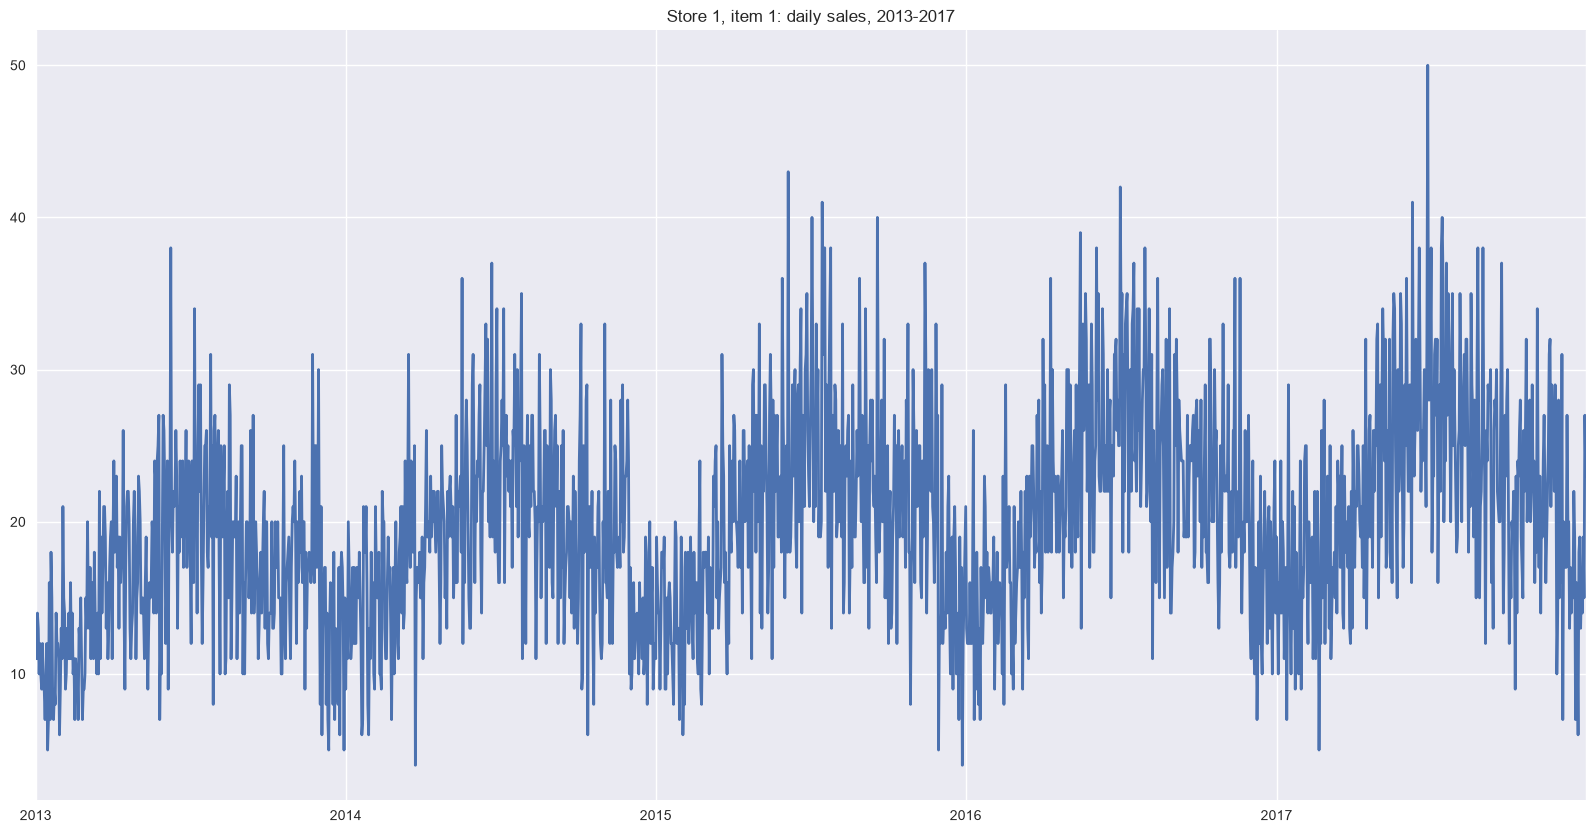

In [9]:
hero = panel[CFG.HERO_ITEM]
hero.plot(linewidth=2, xlabel="",
          title=f"Store {CFG.STORE}, item {CFG.HERO_ITEM}: daily sales, 2013-2017")
print(f"Mean daily sales: {hero.mean():.2f} | min: {hero.min()} | max: {hero.max()}")

The raw series, plotted before any modeling — the series' founding ritual. Item
1 sells about **20 units a day** on average (min
4, max 50), and five years of it show
three structures stacked on top of each other: a slow upward *trend*, a pronounced
annual cycle peaking every summer, and a furry texture of week-scale noise. Nothing
exotic — which is the point. A forecaster that has never seen this series must
recognise all three structures from history alone; we get to watch whether models
pre-trained on other domains actually do.

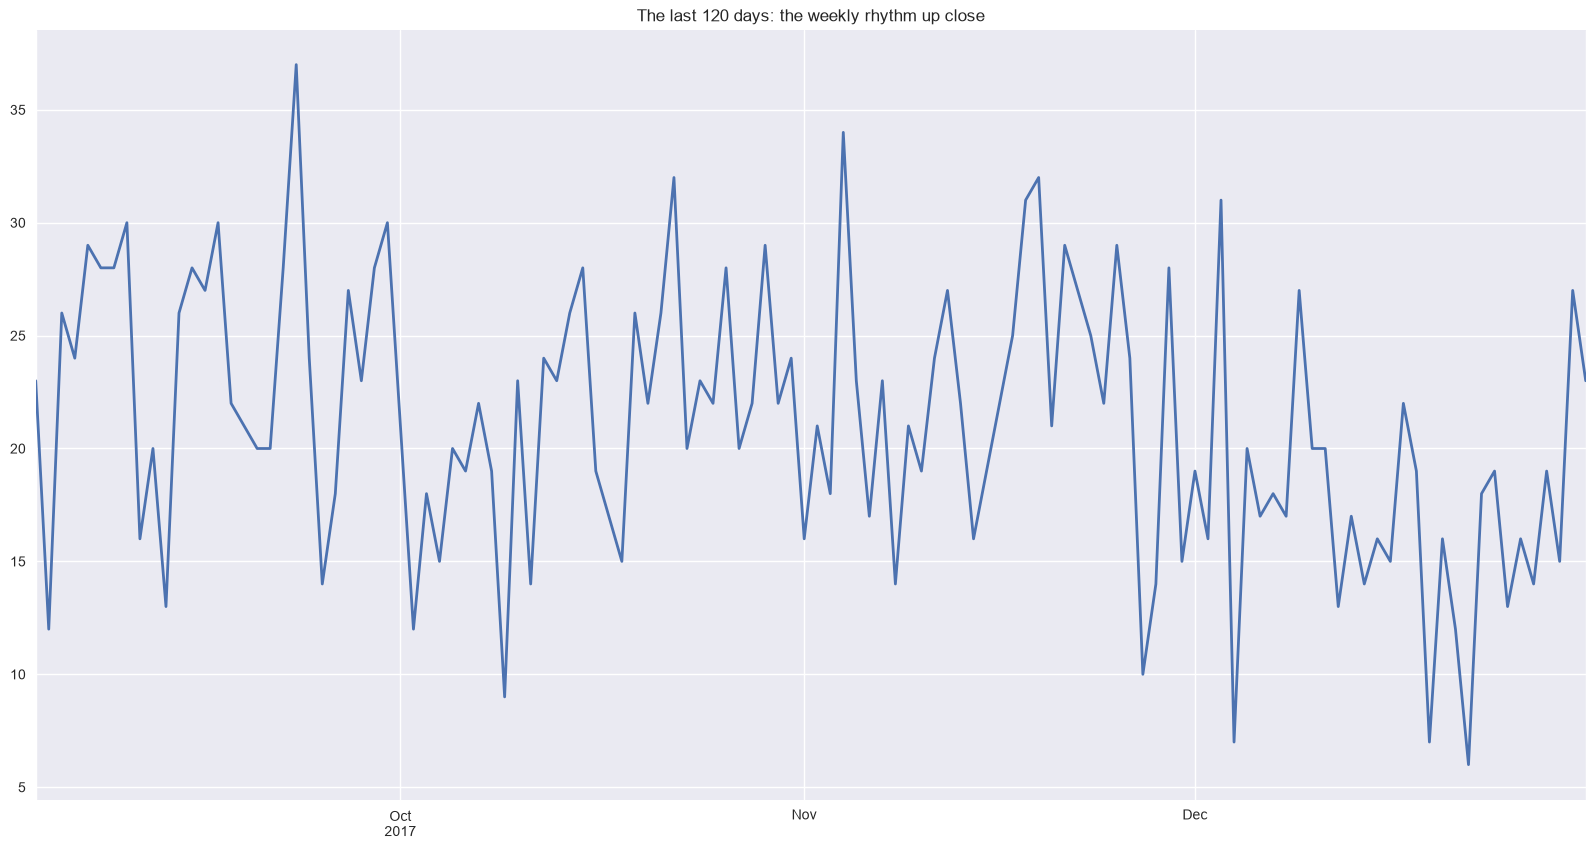

In [10]:
hero.tail(120).plot(linewidth=2, xlabel="",
                    title="The last 120 days: the weekly rhythm up close")
plt.show()

Zooming into the final 120 days reveals the structure the full-history plot smears out:
a stubborn **weekly seesaw**, with weekend peaks and midweek troughs, riding on the
autumn downslope of the annual cycle. Two weeks — our forecast horizon — is exactly two
full periods of this rhythm, so any competent forecaster must reproduce the seesaw, not
just the level. Keep this shape in mind; you will see it echoed (or missed) in every
forecast plot below.

In [11]:
SPLIT_DATE = pd.Timestamp('2017-10-01')
origins = pd.date_range(SPLIT_DATE, periods=CFG.N_ORIGINS, freq='7D')
train_panel = panel[panel.index < SPLIT_DATE]

print("Training days per series:", len(train_panel))
print("First origin:", origins[0].date(), "| last origin:", origins[-1].date())
print("Last forecast day:", (origins[-1] + pd.Timedelta(days=CFG.HORIZON - 1)).date())

Training days per series: 1734
First origin: 2017-10-01 | last origin: 2017-12-17
Last forecast day: 2017-12-30


The chronological split, as always in this series — never a random shuffle, because a
forecaster's job is the future, and shuffling would let it train on days after the ones
it is tested on. Everything before `SPLIT_DATE` (October 1st, 2017) is training
territory: **1,734 days per series**. The final quarter of 2017 becomes a
**walk-forward test**: twelve forecast origins spaced seven days apart
(2017-10-01 through 2017-12-17), each demanding a fresh 14-day forecast,
with the last one landing on December 30th. Twelve origins × ten items = **120
two-week forecasts** per model — enough to average out the luck of any single week,
which (foreshadowing) will turn out to matter a great deal.

One honest asymmetry to note: the models we train ourselves get their weights fitted on
the pre-October data. The foundation models were fitted on *whatever their creators
scraped*, frozen long before this notebook ran; at forecast time they see only the same
512-day context ending at each origin. We return to what "training data" means for a
downloaded model in the final section.

In [12]:
origin0 = origins[0]
actual0 = actuals_for(CFG.HERO_ITEM, origin0)
context0 = context_for(CFG.HERO_ITEM, origin0, CFG.CONTEXT)

# repeat the last observed value for 14 days
naive_forecast = np.repeat(context0[-1], CFG.HORIZON)
# repeat the last observed week, twice
snaive_forecast = np.tile(context0[-7:], 3)[:CFG.HORIZON]

print("Naive:         ", forecast_metrics(actual0, naive_forecast))
print("Seasonal naive:", forecast_metrics(actual0, snaive_forecast))

Naive:          {'mae': 11.07, 'rmse': 12.03}
Seasonal naive: {'mae': 5.36, 'rmse': 6.53}


Before anything with parameters, the two baselines that every forecasting claim must
survive. The **naive** forecast repeats the last observed value fourteen times
(`np.repeat`); the **seasonal naive** repeats the last observed *week* (`np.tile` lays
the final seven days end to end three times, and the slice keeps fourteen). At the
first origin on our close-up series the gap between them is enormous: RMSE
**12.03** for naive versus **6.53** for
seasonal naive. That single comparison already proves the weekly cycle carries most of
the predictable signal — copying last week is nearly twice as good as copying
yesterday. Seasonal naive is therefore the bar to clear: it costs nothing, trains
nothing, and knows nothing except "weeks repeat". Every sophisticated model below earns
its keep only by beating it.

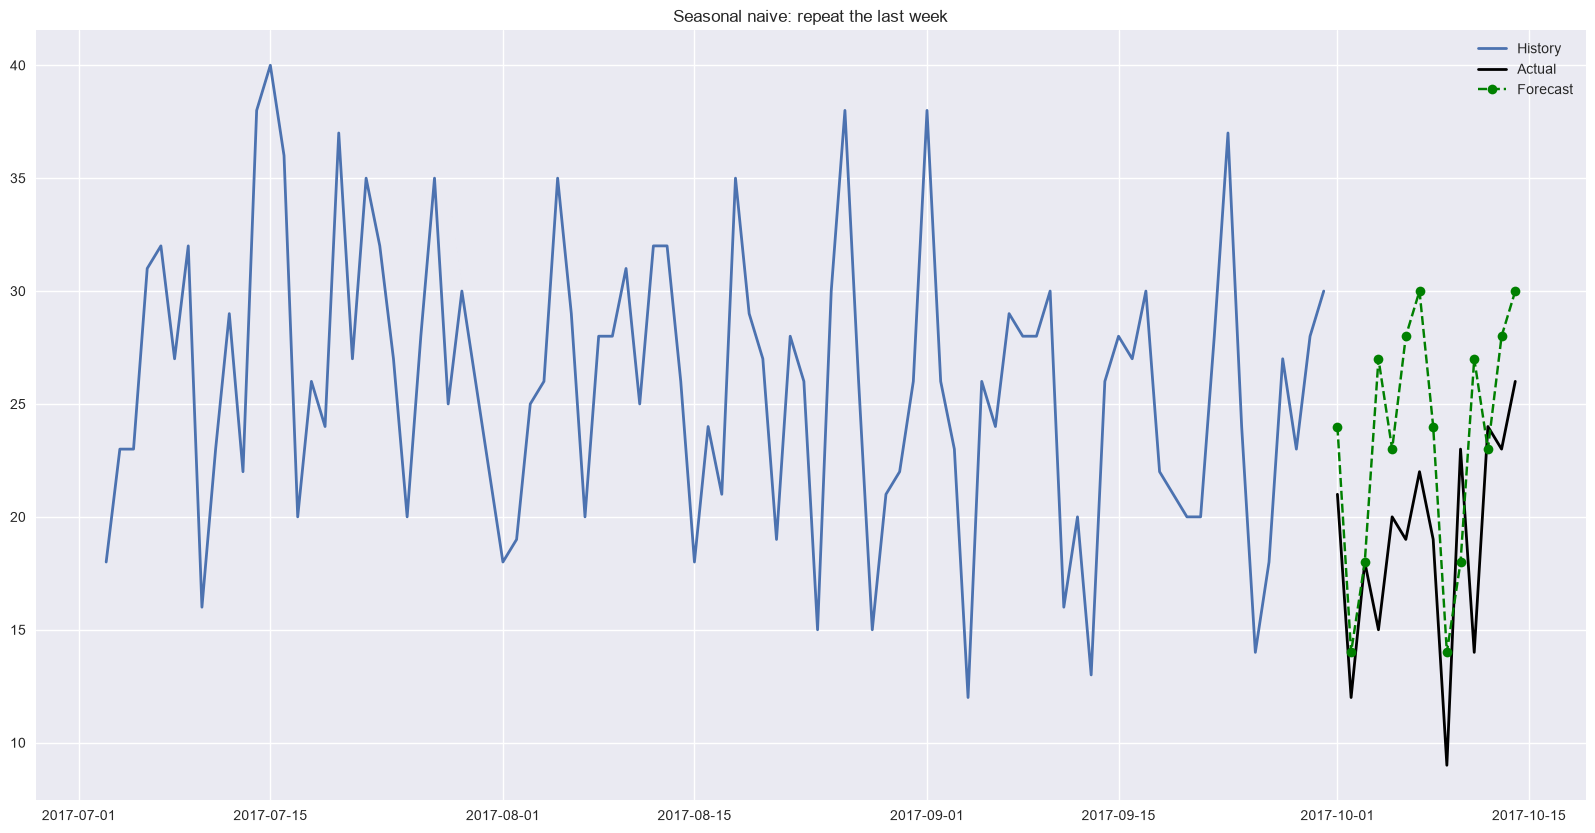

In [13]:
plot_forecast(CFG.HERO_ITEM, origin0, snaive_forecast,
              "Seasonal naive: repeat the last week")

The seasonal naive forecast drawn against reality. It nails the *shape* — the weekend
peaks land on weekends — but copies last week's level and noise verbatim, wiggles and
all. Its two systematic errors are visible at a glance: it cannot know the annual cycle
is still sloping down, and it treats last week's random bumps as gospel. Those two
failure modes — level drift and noise-copying — are precisely the headroom that any
learned model has to work with.

# The specialist paradigm: train your own

First, the incumbent workflow this entire episode interrogates: pick an architecture,
fit it to your data, forecast. We field two specialists from previous episodes, trained
on the pooled windows of all ten arena items — a small taste of cross-series learning,
and the strongest reasonable version of the "train your own" approach at this data
scale. Both models predict all fourteen days in one shot (the *direct* multi-step
strategy), and both work on per-item standardised data so that one shared network can
serve ten series with different levels.

The ladder inside this section is short and familiar: a **linear** model — the
embarrassingly simple baseline that the transformer episode showed beating far fancier
architectures — and then a **GRU**, the best recurrent forecaster from the
deep-learning episode. What is new is that we now account for their *cost*: parameters
trained, seconds spent, and the fact that every new dataset means paying that cost
again.

## A linear forecaster

In [14]:
train_stats = {item: (float(train_panel[item].mean()), float(train_panel[item].std()))
               for item in CFG.ARENA_ITEMS}

X_list, Y_list = [], []
for item in CFG.ARENA_ITEMS:
    mean, std = train_stats[item]
    z = (train_panel[item].to_numpy() - mean) / std
    X_item, Y_item = make_windows(z, CFG.LOOKBACK, CFG.HORIZON)
    X_list.append(X_item)
    Y_list.append(Y_item)

X_all = np.concatenate(X_list).astype('float32')
Y_all = np.concatenate(Y_list).astype('float32')

# hold out the most recent 10% of each item's windows for validation
offsets = np.cumsum([0] + [len(x) for x in X_list[:-1]])
val_idx = np.concatenate([np.arange(len(x))[-int(0.1 * len(x)):] + off
                          for x, off in zip(X_list, offsets)])
val_mask = np.zeros(len(X_all), dtype=bool)
val_mask[val_idx] = True
X_train, Y_train = X_all[~val_mask], Y_all[~val_mask]
X_val, Y_val = X_all[val_mask], Y_all[val_mask]

print("Training windows:", X_train.shape, "| validation windows:", X_val.shape)

Training windows: (14740, 84) | validation windows: (1630, 84)


The data pipeline for the specialists, in three moves. First, **per-item
standardisation**: each item's training mean and standard deviation go into
`train_stats`, and each series is z-scored with *its own* statistics — computed on
training data only, so no test information leaks into the scaling. This is what lets
one network serve items that sell 15 a day and items that sell 60: in z-space they all
live on the same scale. We keep the dictionary because every model output must be
mapped back to sales units through the same statistics before scoring.

Second, `make_windows` slices each standardised series into (84-day input, 14-day
target) pairs, and `np.concatenate` pools all ten items into one training set:
**16,370 windows** in total.

Third, validation. A random split would leak here exactly as it would in the original
series: neighbouring windows share 83 of 84 days. So we hold out the most recent 10%
of *each item's* windows — the index arithmetic with `offsets` just translates
"last 10% per item" into positions in the pooled array — giving
14,740 training and 1,630 validation windows, with validation
chronologically after training within every item. Early stopping will watch this
validation loss.

In [15]:
keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    linear_model = keras.Sequential([
        keras.layers.Input((CFG.LOOKBACK,)),
        keras.layers.Dense(CFG.HORIZON)
    ])
linear_model.compile(optimizer='adam', loss='mse')

start = time.time()
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history_linear = linear_model.fit(X_train, Y_train,
                                  validation_data=(X_val, Y_val),
                                  epochs=50, batch_size=256,
                                  callbacks=[early_stop], verbose=0)
linear_train_time = time.time() - start

print(f"Parameters: {linear_model.count_params():,}")
print(f"Training: {linear_train_time:.1f}s"
      f" ({len(history_linear.history['loss'])} epochs)")

Parameters: 1,190
Training: 4.5s (28 epochs)


The linear specialist: a single `Dense(14)` layer mapping 84 input days straight to 14
output days — no activation, no hidden layers, just one 84×14 weight matrix plus
biases, **1,190 parameters** in all. The transformer episode's
DLinear lesson was that this humble map is brutally hard to beat on well-behaved
seasonal data, so it earns its place as the first specialist.

Two idioms to note, both carried over from earlier episodes. `keras.utils.set_random_seed`
is called immediately **before the model is built**, not before `fit` — weight
initialisation draws from the global generator, so seeding late would leave the init
irreproducible (a mistake that silently shifted results in the transfer-learning
episode). And the model is constructed inside `with keras.device(DEVICE):`, which
places its weights on the MPS GPU; the PyTorch backend then runs the whole `fit` there.

Training is almost embarrassingly cheap: `EarlyStopping` with `patience=5` watches the
validation loss, `restore_best_weights=True` rolls back to the best epoch, and the run
stops after 28 epochs — **4.5s** on the Apple
GPU. Remember that number; it is the cost the zero-shot models claim to eliminate.

In [16]:
def forecast_all_origins(model, needs_3d=False):
    """Forecast every (origin, item) pair with a trained window model."""
    contexts, keys = [], []
    for origin in origins:
        for item in CFG.ARENA_ITEMS:
            mean, std = train_stats[item]
            z_context = (context_for(item, origin, CFG.LOOKBACK) - mean) / std
            contexts.append(z_context)
            keys.append((origin, item))

    batch = np.array(contexts, dtype='float32')
    if needs_3d:
        batch = batch[..., None]
    predictions = model.predict(batch, verbose=0)

    forecasts = {}
    for key, pred in zip(keys, predictions):
        mean, std = train_stats[key[1]]
        forecasts[key] = pred * std + mean
    return forecasts

A helper we will reuse for both specialists, and the pattern to imitate whenever you
walk a window model forward through test origins. For every (origin, item) pair it
takes the last 84 days before the origin via `context_for`, standardises with that
item's *training* statistics, and stacks all 120 contexts into one batch so `predict`
runs a single GPU pass instead of 120 tiny ones. `needs_3d` handles the shape
difference between the two specialists: the recurrent model wants `(batch, time,
features)`, so we grow a trailing feature axis with `[..., None]`. Each prediction is
then mapped back to sales units — multiply by the item's σ, add its μ — and stored in a
dictionary keyed by (origin, item), the same shape as the actuals, ready for scoring.

Linear on the close-up series: {'mae': 4.63, 'rmse': 5.04}


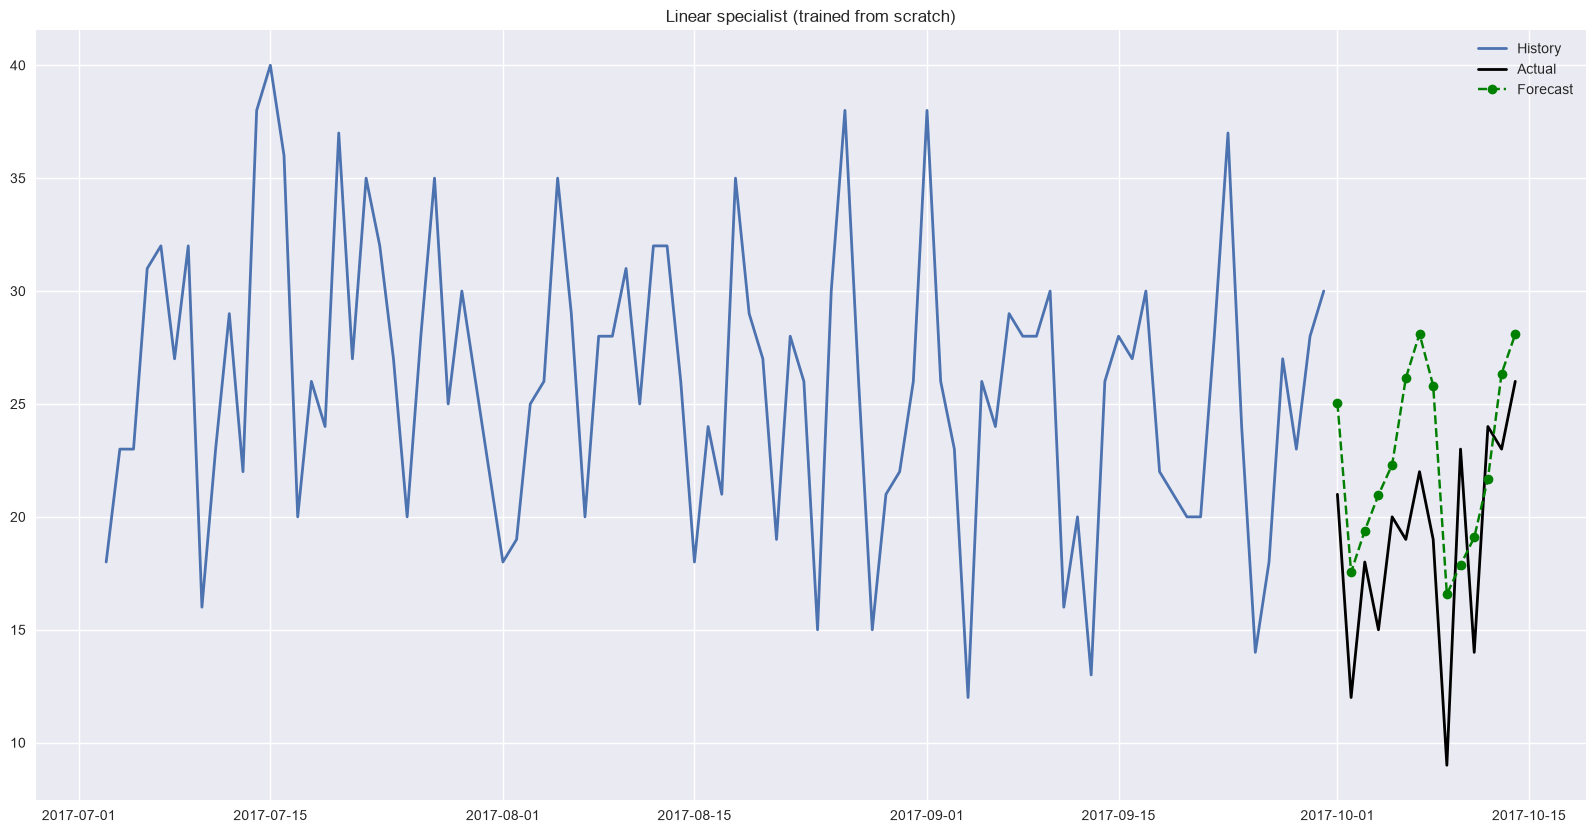

In [17]:
linear_forecasts = forecast_all_origins(linear_model)

hero_key = (origin0, CFG.HERO_ITEM)
print("Linear on the close-up series:",
      forecast_metrics(actual0, linear_forecasts[hero_key]))
plot_forecast(CFG.HERO_ITEM, origin0, linear_forecasts[hero_key],
              "Linear specialist (trained from scratch)")

The linear model's close-up: RMSE **5.04** on the first origin —
a clear improvement over seasonal naive's 6.53, and the plot
shows why. The forecast keeps the weekly seesaw but *smooths away* last week's
idiosyncratic wiggles (it has averaged over sixteen thousand training windows, not
copied one week), and it sits slightly below last week's level, having learned the autumn
downslope. This is exactly the two-part headroom we identified at the baseline, and a
1,190-parameter model captured most of it in five seconds. The bar for the foundation
models keeps rising.

## A GRU forecaster

In [18]:
keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    gru_model = keras.Sequential([
        keras.layers.Input((CFG.LOOKBACK, 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(CFG.HORIZON)
    ])
gru_model.compile(optimizer='adam', loss='mse')

start = time.time()
early_stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history_gru = gru_model.fit(X_train[..., None], Y_train,
                            validation_data=(X_val[..., None], Y_val),
                            epochs=30, batch_size=256,
                            callbacks=[early_stop], verbose=0)
gru_train_time = time.time() - start

print(f"Parameters: {gru_model.count_params():,}")
print(f"Training: {gru_train_time:.1f}s"
      f" ({len(history_gru.history['loss'])} epochs)")

Parameters: 13,774
Training: 23.5s (19 epochs)


The nonlinear specialist: a 64-unit **GRU** reading the 84 days one step at a time,
its final hidden state feeding a `Dense(14)` head — the champion architecture of the
deep-learning episode, with **13,774 parameters**. The construction
follows the identical ritual (seed, device context, compile), and the inputs grow their
trailing feature axis with `[..., None]` because recurrent layers expect
`(batch, timesteps, features)`.

The cost asymmetry against the linear model is already visible at this toy scale:
about five times the training time (**23.5s**, 19
epochs) for a model that — spoiler from two episodes of experience — may or may not
beat the 84×14 matrix. Now multiply by a realistic catalogue: a retailer with 50,000
series, retrained weekly, is looking at a permanent training pipeline with monitoring,
scheduling and failure handling. That operational bill, not the 24 seconds, is the real
motivation for the zero-shot paradigm.

GRU on the close-up series: {'mae': 5.79, 'rmse': 6.64}


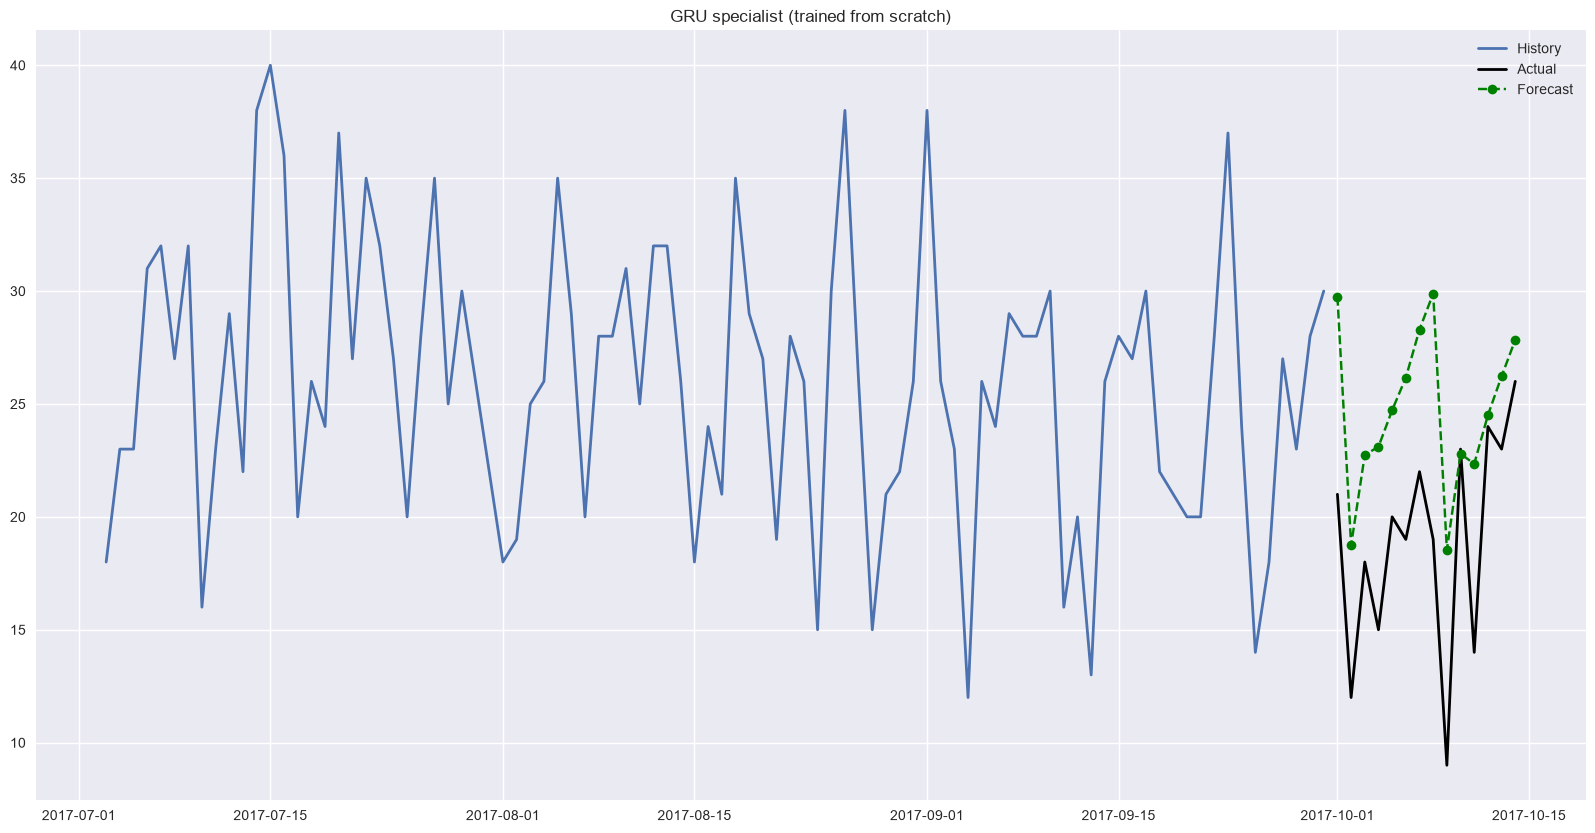

In [19]:
gru_forecasts = forecast_all_origins(gru_model, needs_3d=True)

print("GRU on the close-up series:",
      forecast_metrics(actual0, gru_forecasts[hero_key]))
plot_forecast(CFG.HERO_ITEM, origin0, gru_forecasts[hero_key],
              "GRU specialist (trained from scratch)")

And a first surprise, of the kind this series keeps insisting on showing you unedited:
on this particular origin and item the GRU scores RMSE **6.64** —
*worse* than the linear model's 5.04. One forecast is fourteen
noisy days of one series; single-window rankings are close to coin flips, which is
precisely why the arena later aggregates 120 of them before drawing conclusions. Hold
both judgments loosely until then — but note the pattern echoes the transformer
episode, where the linear model beat far heavier machinery on this same panel.

# How a foundation model reads a series

Before running the foundation models, it pays to understand the one problem every
single one of them had to solve first. A transformer is a machine for sequences of
**tokens** — discrete symbols from a finite vocabulary, each mapped to an embedding
vector. Language arrives pre-tokenized; a time series does not. It is a stream of
continuous floats with no vocabulary, arbitrary scale (sales of 20 a day here, server
requests in the millions elsewhere), and a noise level that makes any single
observation nearly meaningless. Feeding one float per token is also computationally
hostile: self-attention costs grow with the *square* of sequence length.

The field converged on two main answers, and the models we are about to run split
neatly along this line — so we build both answers ourselves, in a few lines of NumPy,
on our own series. (A third answer, constructing tokens from *lagged values* at
seasonal offsets — the route taken by **Lag-Llama**, an early open model from
ServiceNow/Mila — preserves exact values and encodes periodicity explicitly, but has
lost ground to the two below and we won't dwell on it.)

## Patching: sub-sequences as tokens

512 days -> 16 patches (tokens) of 32 days each
Attention cost vs. one-token-per-day: 0.0977%


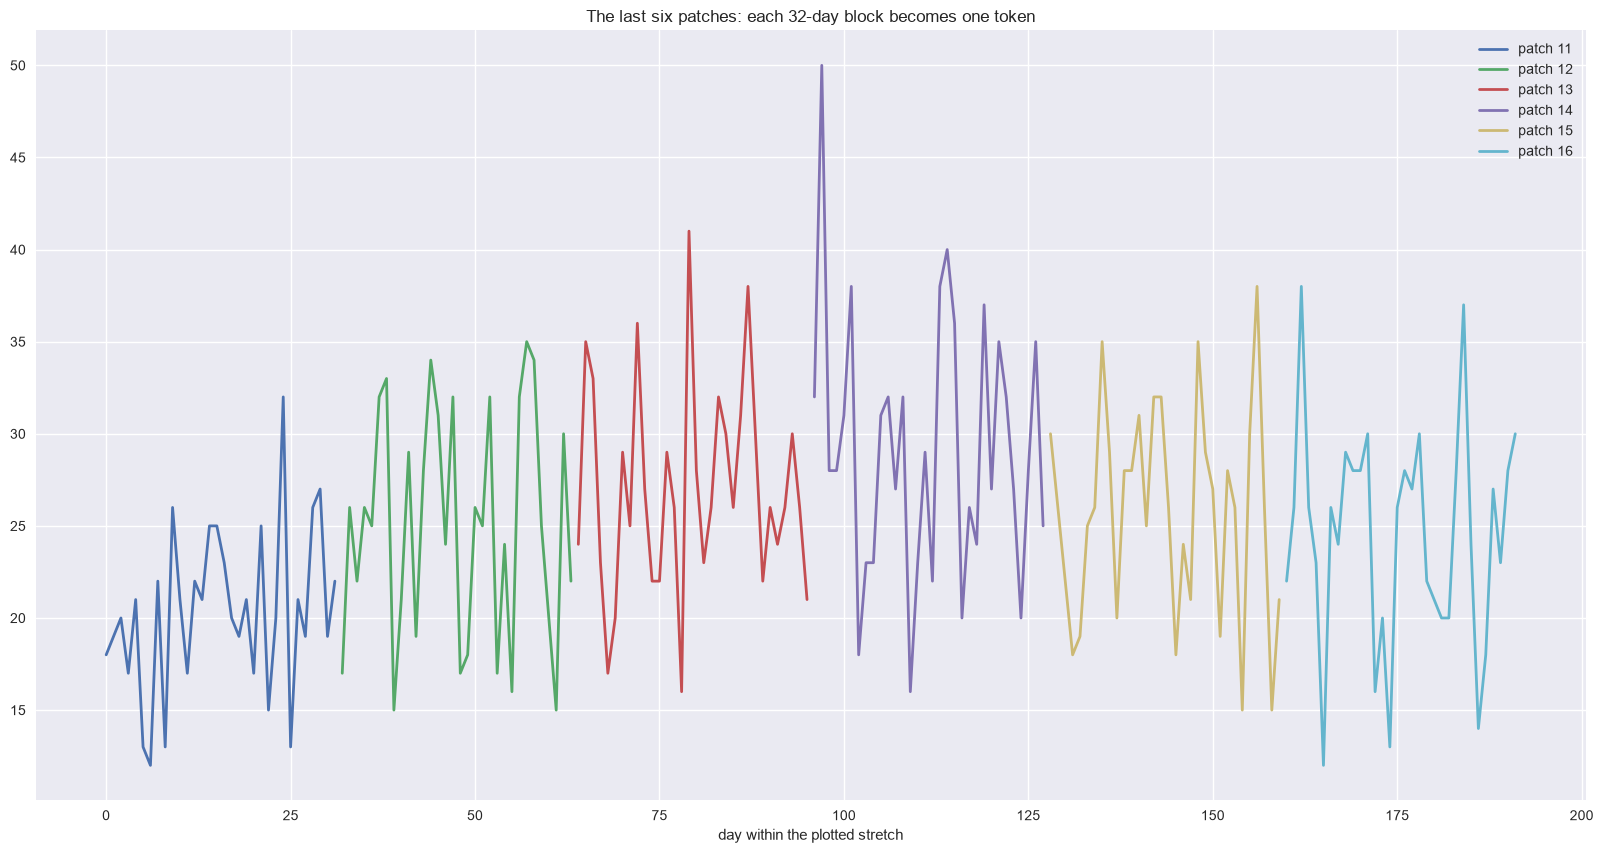

In [20]:
PATCH_LEN = 32
patches = context0.reshape(-1, PATCH_LEN)

print(f"{len(context0)} days -> {patches.shape[0]} patches (tokens) "
      f"of {PATCH_LEN} days each")
print(f"Attention cost vs. one-token-per-day: "
      f"{(patches.shape[0] ** 2) / (len(context0) ** 2):.4%}")

plt.figure()
for i in range(6):
    segment = patches[-6 + i]
    plt.plot(np.arange(i * PATCH_LEN, (i + 1) * PATCH_LEN), segment,
             linewidth=2, label=f"patch {patches.shape[0] - 6 + i + 1}")
plt.title("The last six patches: each 32-day block becomes one token")
plt.xlabel("day within the plotted stretch")
plt.legend()
plt.show()

**Patching** — the answer chosen by TimesFM and most of the field. One `reshape` cuts
the 512-day context into **16 non-overlapping blocks of
32 days**; inside the real model, each block is pushed through a
small MLP to become one embedding vector, and *those* are the tokens the transformer
attends over. The printout shows the economics: 16 tokens instead of 512 shrinks the
attention matrix to **under 0.1%** of its one-token-per-day size — this is what makes
16k-point contexts feasible at all.

The plot shows the semantic argument, which matters as much as the economics. Each
coloured segment — one patch — is a month of data containing four full weekly cycles
and a stretch of the seasonal slope. Like a word compared to a letter, a patch is a
unit *worth attending to*: a single day's value is mostly noise, but a 32-day shape is
a recognisable pattern. The transformer then reasons about relationships between
month-shaped things, not day-shaped things.

## Quantization: sales as sentences

In [21]:
N_BINS = 4096
scale = np.mean(np.abs(context0))
scaled = context0 / scale

bin_edges = np.linspace(scaled.min(), scaled.max(), N_BINS + 1)
tokens = np.clip(np.digitize(scaled, bin_edges) - 1, 0, N_BINS - 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
reconstructed = bin_centers[tokens] * scale

round_trip_rmse = float(np.sqrt(np.mean((context0 - reconstructed) ** 2)))
print("Vocabulary size:", N_BINS)
print("Tokens actually used by this series:", len(np.unique(tokens)))
print("First ten tokens:", tokens[:10])
print("Round-trip error (RMSE, sales units):", round(round_trip_rmse, 4))

Vocabulary size: 4096
Tokens actually used by this series: 37
First ten tokens: [1638 1911 1183 2184 1456 1274 1911 2275 3094  728]
Round-trip error (RMSE, sales units): 0.002


**Quantization** — the opposite philosophy, introduced by the original Amazon
**Chronos**: if transformers are language machines, turn the series *into language*.
Three steps, each one line here. **Mean scaling** divides the series by its mean
absolute value (23.17 for our context), collapsing sales-of-20 and
requests-in-millions onto a common scale. **Binning** chops the scaled range into
`N_BINS = 4096` intervals — the vocabulary — and `np.digitize` assigns each day its
bin id (the `- 1` and `np.clip` convert digitize's 1-based edge convention into safe
0-based token ids). The series is now literally a sentence of integers, and the
printout shows the first ten "words". A T5 language model can be trained on such
sentences with an ordinary cross-entropy loss, predicting a *distribution over the
vocabulary* for the next token — which is where Chronos' probabilistic forecasts
originally came from.

The cost of discretisation turns out to be trivial: decoding each token back to its
bin centre reproduces the series with an RMSE of
**0.002** sales units — invisible next to day-to-day noise. Note
also how few words this series needs: only **37 of the
4,096 tokens** are ever used. The vocabulary is sized for the diversity of a whole
pre-training universe, not one series. The real weakness is subtler than precision
loss: token-by-token generation is slow, and values outside the binned range simply
cannot be represented — one reason the Chronos family later moved on, as we will see.

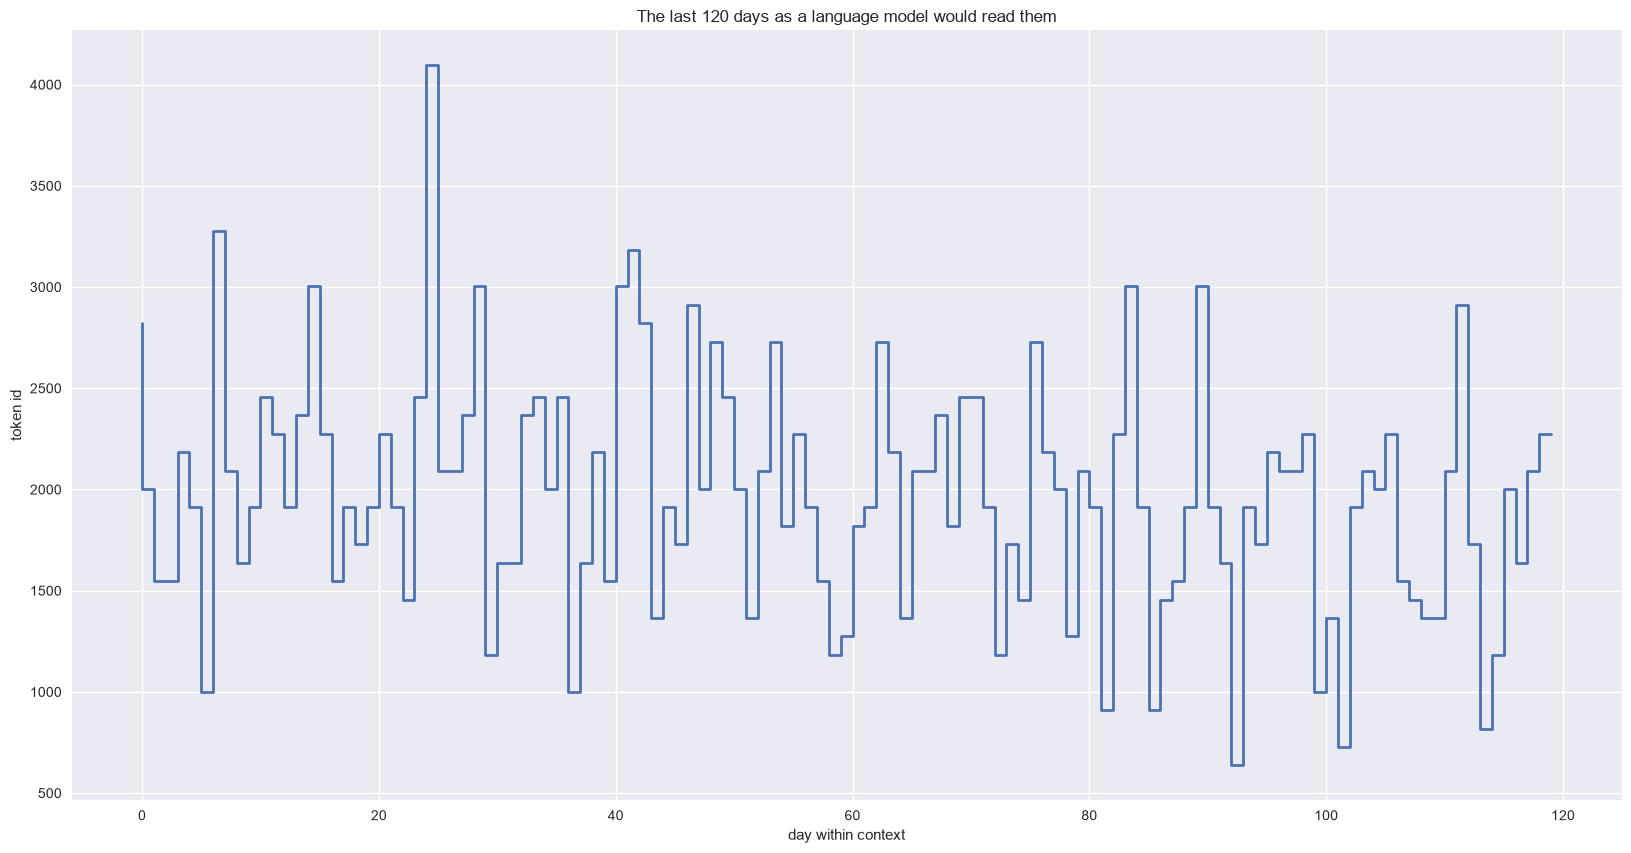

In [22]:
plt.figure()
plt.step(np.arange(120), tokens[-120:], linewidth=2)
plt.title("The last 120 days as a language model would read them")
plt.xlabel("day within context")
plt.ylabel("token id")
plt.show()

The same 120 days we plotted in the groundwork section, now as the token sequence a
language model would consume. The shape is perfectly recognisable — weekly seesaw,
autumn downslope — just written in a 4,096-symbol alphabet instead of floats. This
picture is the entire Chronos hypothesis in one image: *if the structure survives
tokenization, a language model can learn its grammar.*

# The zero-shot ladder

Concepts in hand, we climb through three foundation models, in order of increasing
architectural distance from what we have already built by hand this season. All three
are open-weights, download from Hugging Face, and run on this laptop's GPU. For each
we follow an identical protocol: load, forecast **all 120 (origin, item) tasks** with a
512-day context — timing the whole thing — then inspect the close-up series. Nobody
gets fine-tuned; nobody sees a single training gradient from our data.

| Model | Maker | Backbone | Params | Tokenization | Probabilistic output |
|---|---|---|---|---|---|
| **TimesFM 2.5** | Google | decoder-only transformer | 200M | patches (float) | continuous quantile head |
| **TiRex** | NX-AI | stacked xLSTM (no attention) | 35M | patches + masking | 9-level quantile grid |
| **Chronos-2** | Amazon | transformer w/ group attention | 120M | patches (float) | direct multi-quantile |

Three families from the wider zoo are worth knowing about even though we won't run
them. **Moirai 2.0** (Salesforce) pursues "universal forecasting" hardest: its
any-variate attention flattens an arbitrary number of variables into one sequence, and
its Mixture-of-Experts variant matched dense rivals with up to 65× fewer *active*
parameters; tellingly, version 2.0 abandoned its original masked-encoder design for a
decoder-only one — the whole field has converged there. **Toto 2.0** (Datadog)
specialises in high-cardinality observability telemetry, with a scaling family reaching
2.5B parameters trained on over a trillion points, and two ideas worth stealing:
*causal* patch normalisation (statistics computed only over past patches, so
normalisation itself cannot leak the future) and an arcsinh transform that tames
metrics spanning orders of magnitude. **TimeGPT** (Nixtla) is the API-first option — no
weights, just a client library — with conformal prediction intervals; a pragmatic
choice when you want zero infrastructure, at the price of sending your data out and
trusting a black box. Honourable mentions: **MOMENT** (CMU), a masked encoder built for
classification, imputation and anomaly detection as much as forecasting, and
**Time-MoE**, which scaled sparse mixture-of-experts to 2.4B parameters on 300 billion
time points to show that scaling laws hold for time series too.

## TimesFM 2.5: the patched decoder

In [23]:
start = time.time()
timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch")
timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=CFG.CONTEXT,
        max_horizon=64,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        fix_quantile_crossing=True,
    )
)
print(f"Loaded and compiled in {time.time() - start:.1f}s")

Loaded and compiled in 0.8s


**TimesFM** is Google Research's flagship: a decoder-only transformer over patch
tokens, pre-trained on roughly 100 billion real-world time points — much of it Google
Trends and Wikipedia pageview series, chosen precisely because web attention encodes
human weekly and holiday rhythms that transfer to domains like retail. Version 2.5,
the current one, is leaner and stronger than its predecessors: 200M parameters (down
from 500M in 2.0), a context window stretched to 16,384 points, and no more manual
frequency flag — earlier versions made you declare "this is daily data", 2.5 infers it.

Its architectural signature is the **asymmetric patch**: input patches of 32 points
but *output* patches of 128. A conventional autoregressive model forecasting 256 steps
needs 256 generation steps, each feeding on its own possibly-wrong output; TimesFM
emits 128-point blocks, so long horizons take a couple of forward passes instead of
hundreds — faster, and with less error compounding.

The two-stage setup mirrors its API: `from_pretrained` pulls the checkpoint, then
`compile` fixes an inference configuration. `max_context=512` matches our diet;
`normalize_inputs` lets the model handle scaling internally (the reason we can feed
raw sales while our Keras models needed hand-built z-scoring);
`use_continuous_quantile_head` activates an optional 30M-parameter head that emits
deciles alongside the point forecast — quantile forecasting as an architectural
add-on; and `fix_quantile_crossing` post-processes those deciles so the 90th never
dips below the 10th, a small but real pathology of independently-predicted quantiles.

In [24]:
timesfm_point, timesfm_quantiles = {}, {}

start = time.time()
for origin in origins:
    inputs = [context_for(item, origin, CFG.CONTEXT).astype('float32')
              for item in CFG.ARENA_ITEMS]
    point, quantiles = timesfm_model.forecast(horizon=CFG.HORIZON, inputs=inputs)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        timesfm_point[(origin, item)] = point[j]
        timesfm_quantiles[(origin, item)] = quantiles[j]  # (14, 10): mean, q10..q90
timesfm_time = time.time() - start

print(f"All {len(origins) * len(CFG.ARENA_ITEMS)} two-week forecasts "
      f"in {timesfm_time:.1f}s - zero training")

All 120 two-week forecasts in 6.3s - zero training


The entire "modeling" workflow of the new paradigm is this loop: hand over raw history,
receive forecasts. `forecast` takes a plain list of NumPy arrays — one per series, no
windowing, no scaling, no feature engineering — and returns two arrays per series: a
point forecast of shape (14,) and a quantile block of shape (14, 10), whose columns
are the mean followed by the ten deciles q10 through q90. We stash both in
dictionaries keyed by (origin, item), the exact shape our specialists' forecasts live
in, so the arena can score everyone identically.

The punchline is the clock: **all 120 two-week forecasts in about
6.3 seconds**, having never seen a gradient from our data. Recall
the GRU needed 23.5s of training before it could forecast anything —
and that cost recurs for every new dataset, while this one never does.

TimesFM 2.5: {'mae': 4.95, 'rmse': 5.55}
80% interval coverage: 0.64


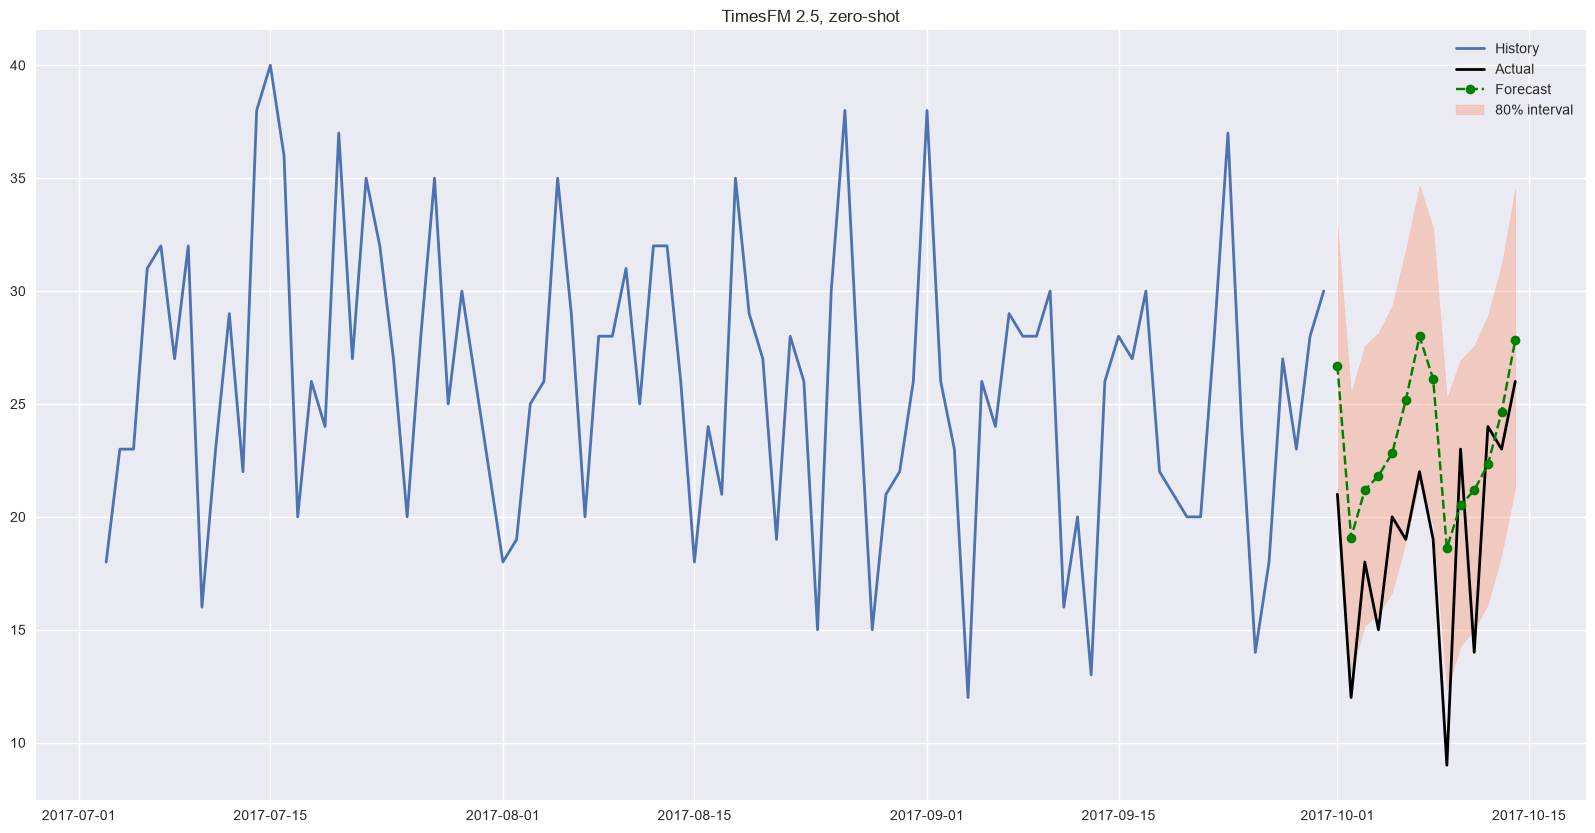

In [25]:
q = timesfm_quantiles[hero_key]
print("TimesFM 2.5:", forecast_metrics(actual0, timesfm_point[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 1], q[:, 9]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, timesfm_point[hero_key],
              "TimesFM 2.5, zero-shot", lower=q[:, 1], upper=q[:, 9])

The close-up verdict: RMSE **5.55** — comfortably better than
seasonal naive (6.53) and the GRU (6.64),
a shade behind the linear specialist (5.04), from a model that
learned everything it knows about retail from *other* time series. The plot shows a
genuinely learned forecast, not a copied week: smooth weekly seesaw, correctly
depressed level, and — new for this series — a coral uncertainty band from the
quantile head.

The band is the thing to scrutinise. Its coverage here is
**64%** against the nominal 80% — over fourteen days,
that's a couple of escapees more than promised, and too small a sample to judge; the
arena will pool 168 days per model before ruling on calibration. Note the band's
*shape* though: it widens visibly with horizon, day 14 admitting more doubt than day
1. That fan is textbook forecasting behaviour, produced zero-shot.

## TiRex: recurrence strikes back

In [26]:
start = time.time()
tirex_model = load_tirex("NX-AI/TiRex", device=DEVICE)
print(f"Loaded in {time.time() - start:.1f}s")

tirex_mean, tirex_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = np.stack([context_for(item, origin, CFG.CONTEXT)
                         for item in CFG.ARENA_ITEMS])
    quantiles, mean = tirex_model.forecast(
        context=torch.tensor(contexts, dtype=torch.float32),
        prediction_length=CFG.HORIZON)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        tirex_quantiles[(origin, item)] = quantiles[j].numpy()  # (14, 9): q10..q90
        tirex_mean[(origin, item)] = mean[j].numpy()
tirex_time = time.time() - start

print(f"All 120 forecasts in {tirex_time:.1f}s")

Loaded in 0.3s


All 120 forecasts in 2.3s


**TiRex**, from NX-AI (the Linz lab of LSTM inventor Sepp Hochreiter), is the ladder's
contrarian rung: a foundation model with **no attention at all**. Its backbone is a
stack of **xLSTM** blocks — the 2024 revival of the LSTM with exponential gating and
better parallelism — which changes the economics rather than just the aesthetics. A
transformer must re-attend over the whole context for every new observation, at cost
quadratic in context length; a recurrent model *carries its history* in a fixed-size
hidden state and absorbs each new patch at constant cost. That is why TiRex's natural
habitat is streaming and edge deployment — its makers benchmark it on industrial PLC
hardware with a few GB of RAM — and why the whole model is only **35M parameters**,
roughly a sixth of TimesFM, yet competitive with the largest entries on zero-shot
leaderboards like GIFT-Eval.

One training trick is worth knowing because we met its ancestor in the transfer
episode: **contiguous patch masking** — long masked spans that the model must
reconstruct in parallel during pre-training. At inference the forecast horizon is just
one more masked span, decoded in a single forward pass: no token-by-token generation,
no compounding of one-step errors.

The API is a two-liner: `forecast` takes a batch of raw contexts and returns a
(batch, 14, 9) quantile tensor — the levels q10 through q90 directly, no parametric
distribution in between — plus a mean. Everything lands in our standard dictionaries.
The clock says 2.3s for all 120 forecasts, and a follow-up model,
**TiRex-2**, extends the recipe to multivariate inputs and known-future covariates
(its checkpoint is gated on Hugging Face, so we run the original here).

TiRex: {'mae': 5.04, 'rmse': 5.75}
80% interval coverage: 0.64


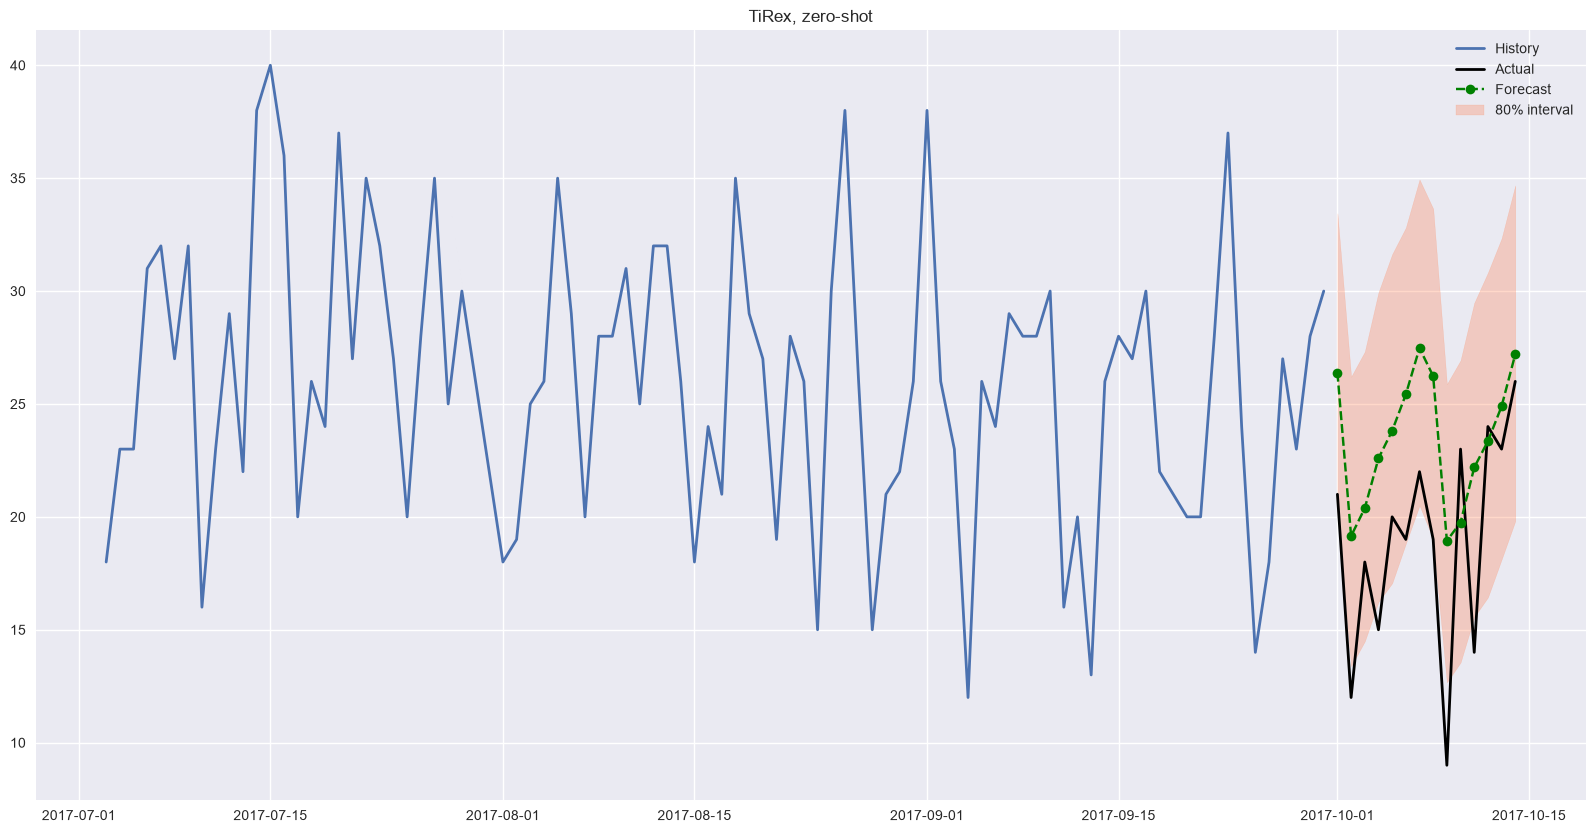

In [27]:
q = tirex_quantiles[hero_key]
print("TiRex:", forecast_metrics(actual0, tirex_mean[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 0], q[:, 8]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, tirex_mean[hero_key],
              "TiRex, zero-shot", lower=q[:, 0], upper=q[:, 8])

RMSE **5.75** on the close-up, with 64%
of actuals inside the 80% band — statistically indistinguishable from TimesFM's
close-up showing, from a model one-sixth the size with a completely different
computational core. (Column indices differ from TimesFM only because TiRex returns
the nine quantiles without a leading mean column: index 0 is q10, index 8 is q90.)
The deeper lesson of this rung: at today's scale of pre-training data, the *backbone*
— attention versus recurrence — matters less than the recipe of patches, masking, and
massive multi-domain exposure. The 2017 architecture war ended in a draw once
everyone got the same food.

## Chronos-2: universal forecasting

In [28]:
start = time.time()
chronos_model = BaseChronosPipeline.from_pretrained("amazon/chronos-2",
                                                    device_map=DEVICE)
print(f"Loaded in {time.time() - start:.1f}s")

chronos_mean, chronos_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = torch.tensor(
        np.stack([context_for(item, origin, CFG.CONTEXT)
                  for item in CFG.ARENA_ITEMS]),
        dtype=torch.float32).unsqueeze(1)   # (10 series, 1 variate, 512 days)
    q_list, mean_list = chronos_model.predict_quantiles(
        contexts, prediction_length=CFG.HORIZON,
        quantile_levels=CFG.QUANTILES)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        chronos_quantiles[(origin, item)] = q_list[j][0].numpy()  # (14, 3)
        chronos_mean[(origin, item)] = mean_list[j][0].numpy()
chronos_time = time.time() - start

print(f"All 120 forecasts in {chronos_time:.1f}s")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded in 0.8s


All 120 forecasts in 0.3s


The top rung. The Chronos family began as the purest "time series is a language" bet —
the T5-with-4,096-token-vocabulary design whose tokenizer we rebuilt above. That
original was accurate but slow (sampling token by token), so **Chronos-Bolt** swapped
in patches and direct quantile prediction for a ~250× speedup — and **Chronos-2**, the
current generation we run here (120M parameters), is a near-complete redesign that
keeps only the name: continuous patch embeddings, a single pass predicting all
quantile levels directly, and — its true novelty — **universality**. One checkpoint
handles univariate series, multivariate groups, and known-future covariates, none of
which the tokenized original could represent at all. The family's own journey away
from quantization is the field's verdict on that debate.

Mechanically, note the shape discipline: `predict_quantiles` wants
`(n_series, n_variates, history)`, so ten independent items enter as `(10, 1, 512)`
via `unsqueeze(1)`. It returns per-series quantile tensors at exactly the levels we
request — no decile bookkeeping — and a mean. The clock: **all 120 forecasts in
0.3s**, the fastest of the three, from a model that would have been
the slowest in its first incarnation.

Chronos-2: {'mae': 4.9, 'rmse': 5.62}
80% interval coverage: 0.57


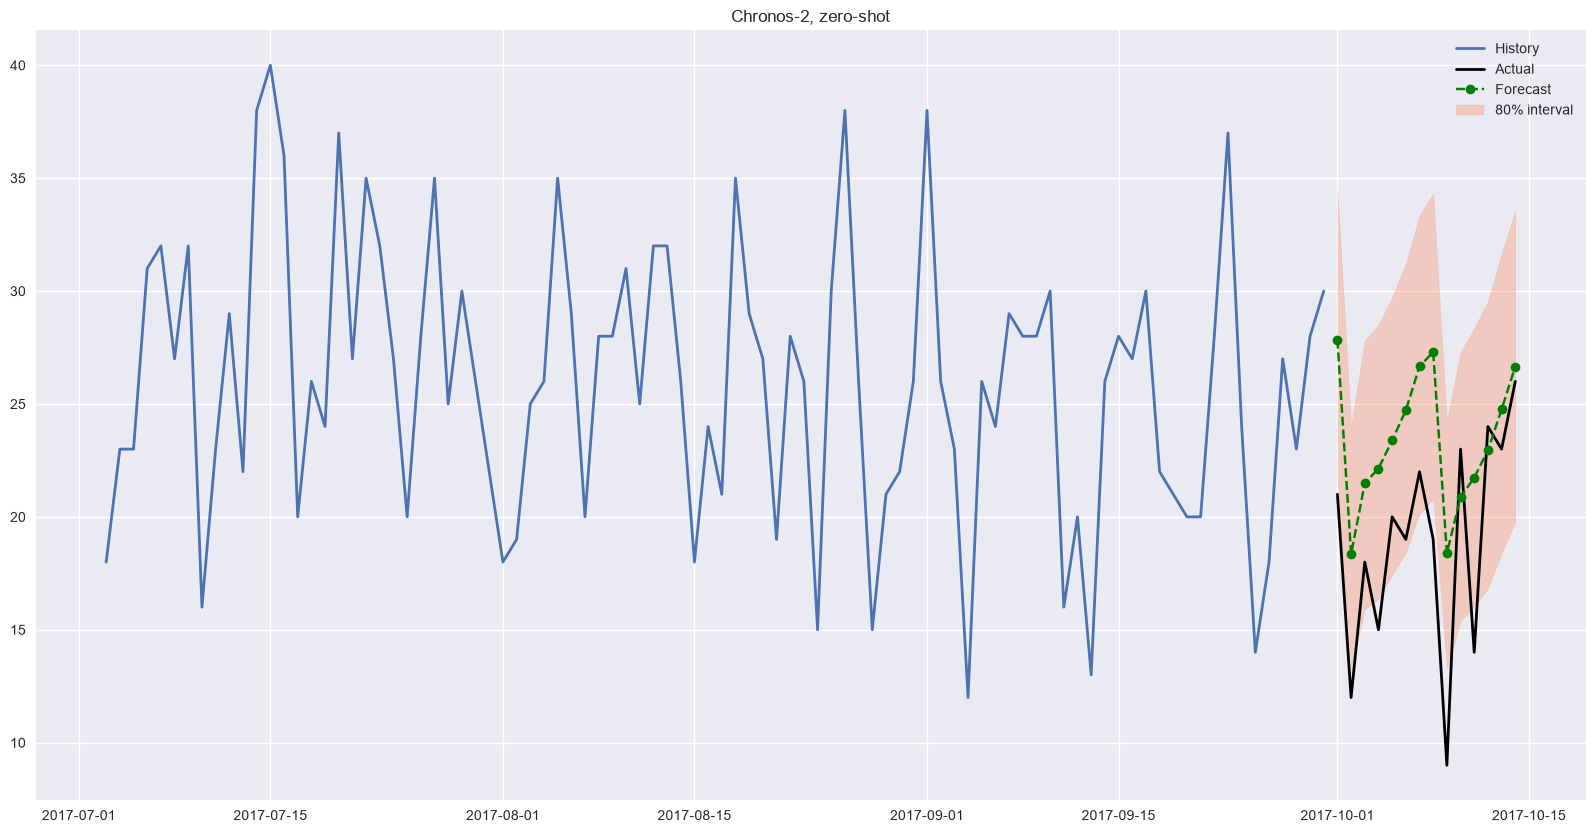

In [29]:
q = chronos_quantiles[hero_key]
print("Chronos-2:", forecast_metrics(actual0, chronos_mean[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 0], q[:, 2]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, chronos_mean[hero_key],
              "Chronos-2, zero-shot", lower=q[:, 0], upper=q[:, 2])

RMSE **5.62** on the close-up — between its two ladder-mates,
with the now-familiar learned seesaw and fanning band (columns 0 and 2 are our
requested q10 and q90). Coverage here is 57%, the lowest of
the three on this single window; again, fourteen days decide nothing. All three
foundation models have now landed in the same close-up neighbourhood — roughly 5.5 to
5.8 RMSE, versus 5.04 for the linear specialist — which is
itself the finding: three alien architectures, trained by three companies on three
different data piles, agree with each other more than they differ from the locals.

In [30]:
all_items = list(panel.columns)

group_mean, group_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = torch.tensor(
        np.stack([context_for(item, origin, CFG.CONTEXT)
                  for item in all_items]),
        dtype=torch.float32).unsqueeze(0)   # (1 task, 50 variates, 512 days)
    q_list, mean_list = chronos_model.predict_quantiles(
        contexts, prediction_length=CFG.HORIZON,
        quantile_levels=CFG.QUANTILES)
    for j, item in enumerate(all_items):
        if item in CFG.ARENA_ITEMS:
            group_quantiles[(origin, item)] = q_list[0][j].numpy()
            group_mean[(origin, item)] = mean_list[0][j].numpy()
group_time = time.time() - start

print(f"Group mode, 50 items jointly: {group_time:.1f}s")
print("Close-up item, forecast alone:     ",
      forecast_metrics(actual0, chronos_mean[hero_key]))
print("Close-up item, forecast in a group:",
      forecast_metrics(actual0, group_mean[hero_key]))

Group mode, 50 items jointly: 0.8s
Close-up item, forecast alone:      {'mae': 4.9, 'rmse': 5.62}
Close-up item, forecast in a group: {'mae': 5.08, 'rmse': 5.71}


Chronos-2's headline feature deserves its own experiment: **in-context learning
across series**. Reshape alone changes the semantics — the same fifty series that
entered the previous cell as fifty independent tasks `(50, 1, 512)` now enter as *one*
task with fifty variates `(1, 50, 512)`. Inside the model, a group-attention layer
lets every series' representation peek at every other's, so it can pick up cross-item
structure on the fly, at inference time, with no weight updates. This is the time
series analogue of prompting an LLM with related examples — and where an LLM's
in-context learning *emerged* from scale, here it is deliberately engineered into the
architecture.

The result is a finding, not a triumph: on the close-up item the group forecast
(RMSE **5.71**) is essentially identical to the solo one
(**5.62**). And it makes sense. These fifty items are siblings
— same store, same weekly rhythm, same summer peak — so item 1's own 512 days already
contain everything its siblings could tell you; the group's information is *redundant*,
not complementary. Context sharing pays when the neighbours know something the target
doesn't: a study on 200 low-voltage electricity feeders found Chronos-2's group mode
genuinely useful when weather covariates were missing, because neighbouring feeders
*were* the weather signal by proxy. Redundant context is at least cheap to include: the twelve group calls
produce forecasts for all fifty items in 0.8s — per series, cheaper than the
ten-item batches above (0.3s). The arena will tell us whether the pattern holds beyond
one item.

# Head-to-head: 120 forecasts, seven forecasters

Close-ups shown, anecdotes collected — time to score everything on the same 120 tasks:
ten items, twelve weekly origins, fourteen days each. Point accuracy (RMSE) for
everyone; pinball loss and 80%-interval coverage for the models that offer quantiles;
and the compute column that the zero-shot paradigm is really about — seconds of
training for the specialists versus seconds of inference for the foundation models.

In [31]:
snaive_forecasts = {}
for origin in origins:
    for item in CFG.ARENA_ITEMS:
        last_week = context_for(item, origin, 7)
        snaive_forecasts[(origin, item)] = np.tile(last_week, 3)[:CFG.HORIZON]

def arena_rmse(forecasts):
    """Pooled RMSE over all (origin, item) tasks."""
    actuals = np.concatenate([actuals_for(item, o)
                              for o in origins for item in CFG.ARENA_ITEMS])
    preds = np.concatenate([forecasts[(o, item)]
                            for o in origins for item in CFG.ARENA_ITEMS])
    return forecast_metrics(actuals, preds)['rmse']

def arena_prob(mean_fc, quantile_fc, lo_col, med_col, hi_col):
    """RMSE + averaged pinball + 80% coverage for a quantile model."""
    actuals = np.concatenate([actuals_for(item, o)
                              for o in origins for item in CFG.ARENA_ITEMS])
    stack = lambda col: np.concatenate([quantile_fc[(o, item)][:, col]
                                        for o in origins
                                        for item in CFG.ARENA_ITEMS])
    lo, med, hi = stack(lo_col), stack(med_col), stack(hi_col)
    means = np.concatenate([mean_fc[(o, item)]
                            for o in origins for item in CFG.ARENA_ITEMS])
    pinball = np.mean([pinball_loss(actuals, lo, 0.1),
                       pinball_loss(actuals, med, 0.5),
                       pinball_loss(actuals, hi, 0.9)])
    return {'rmse': forecast_metrics(actuals, means)['rmse'],
            'pinball': round(float(pinball), 2),
            'coverage_80': round(interval_coverage(actuals, lo, hi), 2)}

Scoring machinery. The seasonal naive dictionary is built the same way as everyone
else's forecasts, so it faces the identical 120 tasks. `arena_rmse` concatenates all
120 × 14 = 1,680 forecast days into one long vector before computing RMSE — pooling
errors across tasks rather than averaging per-task scores, which weights every
forecast day equally. `arena_prob` does the same for the probabilistic outputs; its
`stack` lambda pulls one quantile column out of every stored (14, n_quantiles) block.
The column indices are passed in per model because, as we saw, each library arranges
its quantile axis differently — TimesFM has a leading mean column, TiRex stores nine
deciles, Chronos-2 returns exactly the three levels we requested.

In [32]:
results = []
results.append({'model': 'Seasonal naive (7)', 'zero_shot': '-',
                'rmse': arena_rmse(snaive_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan, 'compute_s': 0.0})
results.append({'model': 'Linear (trained)', 'zero_shot': 'no',
                'rmse': arena_rmse(linear_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan,
                'compute_s': round(linear_train_time, 1)})
results.append({'model': 'GRU (trained)', 'zero_shot': 'no',
                'rmse': arena_rmse(gru_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan,
                'compute_s': round(gru_train_time, 1)})
results.append({'model': 'TimesFM 2.5', 'zero_shot': 'yes',
                **arena_prob(timesfm_point, timesfm_quantiles, 1, 5, 9),
                'compute_s': round(timesfm_time, 1)})
results.append({'model': 'TiRex', 'zero_shot': 'yes',
                **arena_prob(tirex_mean, tirex_quantiles, 0, 4, 8),
                'compute_s': round(tirex_time, 1)})
results.append({'model': 'Chronos-2', 'zero_shot': 'yes',
                **arena_prob(chronos_mean, chronos_quantiles, 0, 1, 2),
                'compute_s': round(chronos_time, 1)})
results.append({'model': 'Chronos-2 (group)', 'zero_shot': 'yes',
                **arena_prob(group_mean, group_quantiles, 0, 1, 2),
                'compute_s': round(group_time, 1)})

results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['zero_shot', 'rmse', 'pinball', 'coverage_80', 'compute_s']]
results_df

,zero_shot,rmse,pinball,coverage_80,compute_s
model,,,,,
Seasonal naive (7),-,11.55,NaN,NaN,0.0
Linear (trained),no,9.46,NaN,NaN,4.5
GRU (trained),no,9.37,NaN,NaN,23.5
TimesFM 2.5,yes,8.30,1.98,0.79,6.3
TiRex,yes,8.76,2.10,0.79,2.3
Chronos-2,yes,7.74,1.86,0.80,0.3
Chronos-2 (group),yes,8.01,1.91,0.79,0.8


The table of the episode. Reading it top to bottom:

- **Seasonal naive: 11.55.** The free baseline, and the
  yardstick for everything below.
- **The trained specialists: 9.46 (linear) and
  9.37 (GRU).** Both clear the baseline by a wide margin —
  and, with 120 forecasts instead of one, the close-up verdict flips: the GRU edges
  out the linear model after all. Single-window rankings deceive; walk-forward
  aggregates decide.
- **The foundation models: 8.3, 8.76,
  7.74.** All three beat both specialists, zero-shot.
  **Chronos-2 wins the arena outright** at 7.74 — roughly 17%
  better than the GRU and 33% better than seasonal naive — with TimesFM second and
  TiRex, at a sixth of the parameters, third yet still ahead of everything trained
  here. The group variant lands at 8.01: the close-up
  pattern holds, redundant sibling context does not add accuracy on this panel.
- **Calibration, the quiet star.** Coverage of the 80% bands:
  79%, 79%, and
  80% across 1,680 forecast days. All three are within a
  point of nominal — uncertainty estimates you could hand to an inventory planner
  as-is, produced for series the models had never seen. Getting intervals this honest
  from a hand-built model requires the entire conformal-prediction apparatus of
  episode seven. Pinball losses rank the same way (1.86 /
  1.98 / 2.1), so Chronos-2's win is not
  a point-forecast artefact.
- **The compute column** is the paradigm in one glance: the specialists *spent* their
  seconds before they could forecast at all and must spend them again for the next
  dataset; the foundation models' seconds are one-off inference, amortising a
  pre-training bill someone else already paid.

One caveat before declaring a new world order: fifty well-behaved daily retail series
with strong weekly seasonality is *home turf* for models pre-trained on exactly such
patterns. Hold that thought for two sections.

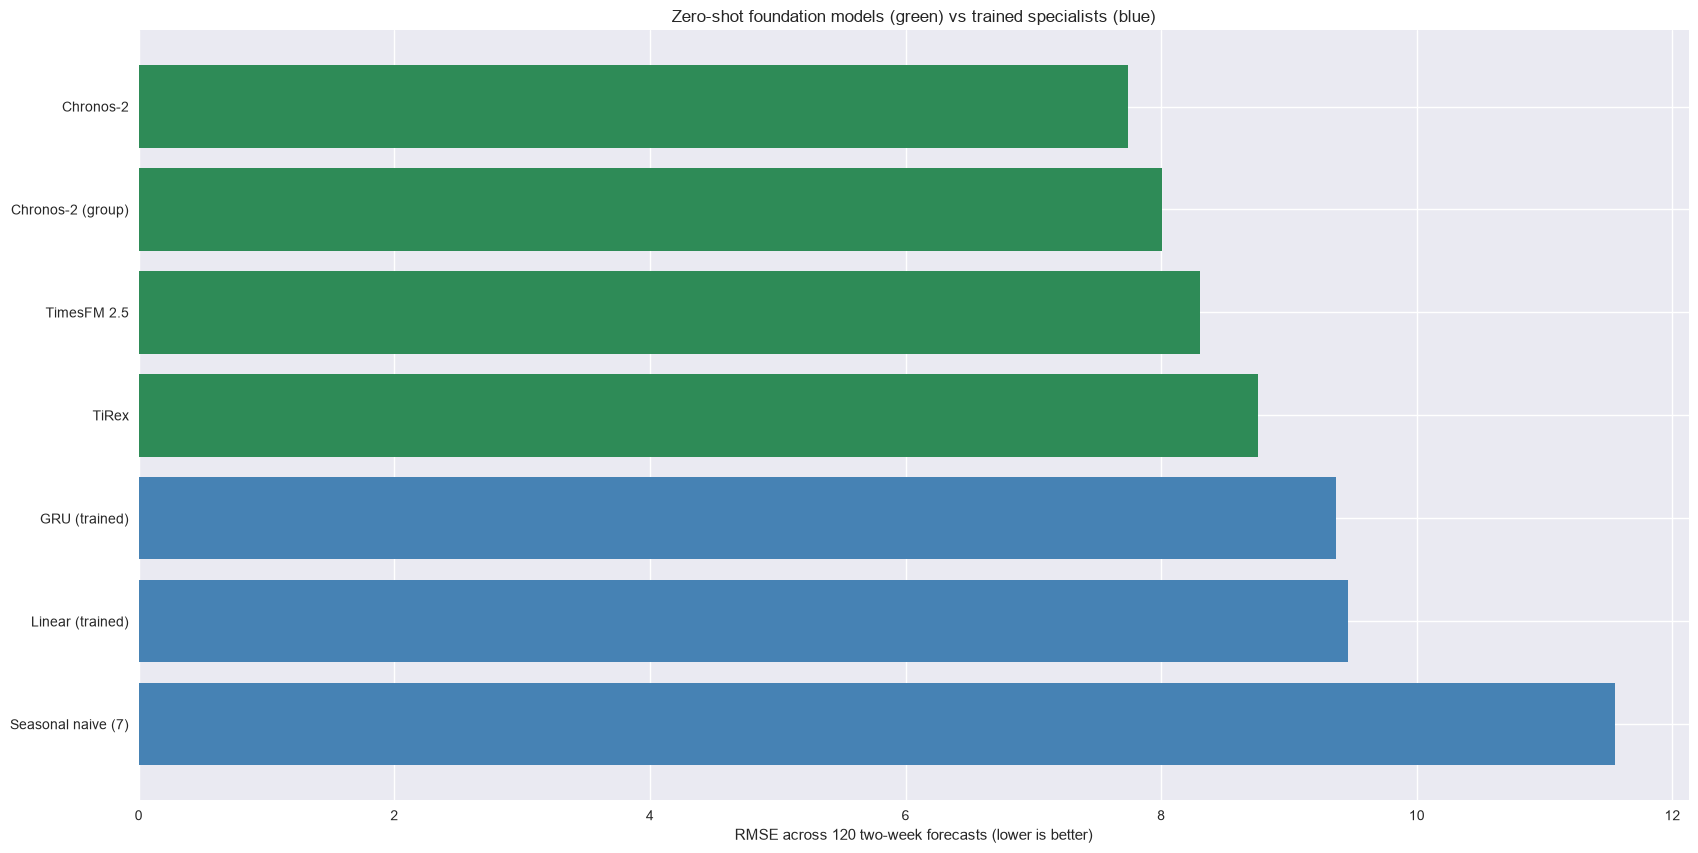

In [33]:
plot_df = results_df.sort_values('rmse', ascending=False)
colors = ['seagreen' if z == 'yes' else 'steelblue' for z in plot_df['zero_shot']]

plt.figure()
plt.barh(plot_df.index, plot_df['rmse'], color=colors)
plt.xlabel("RMSE across 120 two-week forecasts (lower is better)")
plt.title("Zero-shot foundation models (green) vs trained specialists (blue)")
plt.show()

The same verdict as a picture, with the field sorted so the best forecaster ends up on
top: every green
bar (zero-shot) is shorter than every blue bar (trained on this very dataset). The
spread *within* the greens — Chronos-2 to TiRex — is smaller than the gap between the
greens and the blues, which is the practical headline: on this kind of data, *which*
foundation model you pick matters less than *whether* you pick one.

# Application: the cold-start problem

The arena gave every model five years of history — the setting where "train your own"
is strongest. The advertised sweet spot of foundation models is the opposite corner:
a series too *young* to train on. A product launched two months ago, a sensor
installed last quarter, a store opened in spring. Simulation: we hand every approach
only the **last 60 days** of the close-up item's history before the first origin, and
ask for the same 14-day forecast. For the specialists we shrink the window to 28 days
— with 60 days you cannot even fill an 84-day lookback once.

In [34]:
COLD_DAYS = 60
COLD_LOOKBACK = 28
cold_context = context_for(CFG.HERO_ITEM, origin0, COLD_DAYS)

cold_scores = {}
cold_scores['Seasonal naive (7)'] = forecast_metrics(
    actual0, np.tile(cold_context[-7:], 3)[:CFG.HORIZON])['rmse']

# scratch models on 60 days: standardise, window, train
cold_mean, cold_std = float(cold_context.mean()), float(cold_context.std())
z_cold = (cold_context - cold_mean) / cold_std
X_cold, Y_cold = make_windows(z_cold, COLD_LOOKBACK, CFG.HORIZON)
print("Training windows available:", X_cold.shape[0])

keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    linear_cold = keras.Sequential([
        keras.layers.Input((COLD_LOOKBACK,)),
        keras.layers.Dense(CFG.HORIZON)
    ])
linear_cold.compile(optimizer='adam', loss='mse')
linear_cold.fit(X_cold, Y_cold, epochs=200, batch_size=8, verbose=0)
pred = linear_cold.predict(z_cold[-COLD_LOOKBACK:][None, :],
                           verbose=0)[0] * cold_std + cold_mean
cold_scores['Linear (trained on 60d)'] = forecast_metrics(actual0, pred)['rmse']

keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    gru_cold = keras.Sequential([
        keras.layers.Input((COLD_LOOKBACK, 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(CFG.HORIZON)
    ])
gru_cold.compile(optimizer='adam', loss='mse')
gru_cold.fit(X_cold[..., None], Y_cold, epochs=200, batch_size=8, verbose=0)
pred = gru_cold.predict(z_cold[-COLD_LOOKBACK:][None, :, None],
                        verbose=0)[0] * cold_std + cold_mean
cold_scores['GRU (trained on 60d)'] = forecast_metrics(actual0, pred)['rmse']

Training windows available: 19


The starved specialists. Sixty days of history minus a 28-day window minus a 14-day
target leaves **19 training windows** — where the arena versions had
sixteen thousand. We train both scratch architectures anyway, giving them every
chance: 200 epochs, tiny batches, the same seeded, deviced construction ritual as
before (each gets a fresh seed call so the run is reproducible). Note the scaling
statistics now come from the 60 cold days themselves — there is no other history to
compute them from, which is itself part of the cold-start handicap: even the *mean*
is poorly estimated. This is the regime where "just fit a neural network" stops being
advice and starts being a prank.

In [35]:
# foundation models get the same 60 days as context
point, quantiles = timesfm_model.forecast(horizon=CFG.HORIZON,
                                          inputs=[cold_context.astype('float32')])
cold_scores['TimesFM 2.5 (60d ctx)'] = forecast_metrics(actual0, point[0])['rmse']

tirex_q_cold, tirex_m_cold = tirex_model.forecast(
    context=torch.tensor(cold_context, dtype=torch.float32).unsqueeze(0),
    prediction_length=CFG.HORIZON)
cold_scores['TiRex (60d ctx)'] = forecast_metrics(
    actual0, tirex_m_cold[0].numpy())['rmse']

q_list, mean_list = chronos_model.predict_quantiles(
    torch.tensor(cold_context, dtype=torch.float32).reshape(1, 1, -1),
    prediction_length=CFG.HORIZON, quantile_levels=CFG.QUANTILES)
cold_scores['Chronos-2 (60d ctx)'] = forecast_metrics(
    actual0, mean_list[0][0].numpy())['rmse']

# references from the full-history world, same origin and item
cold_scores['GRU (trained, full history)'] = forecast_metrics(
    actual0, gru_forecasts[hero_key])['rmse']
cold_scores['Chronos-2 (512d ctx)'] = forecast_metrics(
    actual0, chronos_mean[hero_key])['rmse']

cold_df = pd.DataFrame.from_dict(cold_scores, orient='index',
                                 columns=['rmse']).sort_values('rmse')
cold_df

,rmse
Chronos-2 (512d ctx),5.62
TiRex (60d ctx),5.91
Chronos-2 (60d ctx),6.11
Seasonal naive (7),6.53
"GRU (trained, full history)",6.64
TimesFM 2.5 (60d ctx),6.68
GRU (trained on 60d),6.74
Linear (trained on 60d),8.47


The foundation models take the identical 60-day array — the calls are unchanged except
for the shorter context — and two full-history references join the table for
perspective. The ranking tells the cold-start story cleanly:

- **The zero-shot models degrade gracefully.** TiRex (5.91) and
  Chronos-2 (6.11) lead the 60-day field — and TiRex on 60 days
  even beats the GRU trained on *five years* (6.64).
  Sixty days is two months of weekly cycles: enough for a model that has seen a
  million weekly rhythms to lock on.
- **The starved specialists don't.** The 60-day linear model
  (8.47) finishes *behind seasonal naive*
  (6.53) — nineteen windows cannot estimate an honest 28×14
  map — and the 60-day GRU (6.74) essentially ties the free
  baseline. Training on a cold series buys you complexity risk, not accuracy.
- **History still helps the history-lovers.** Chronos-2 with its full 512-day context
  (5.62) remains the best number in the table — a foundation
  model is not a reason to throw history away; it is a way to survive not having any.

Standard caveat: this is one origin of one item — a demonstration of the mechanism,
not a benchmark. (The mechanism replicates: the pattern above is exactly what the
literature reports at scale.)

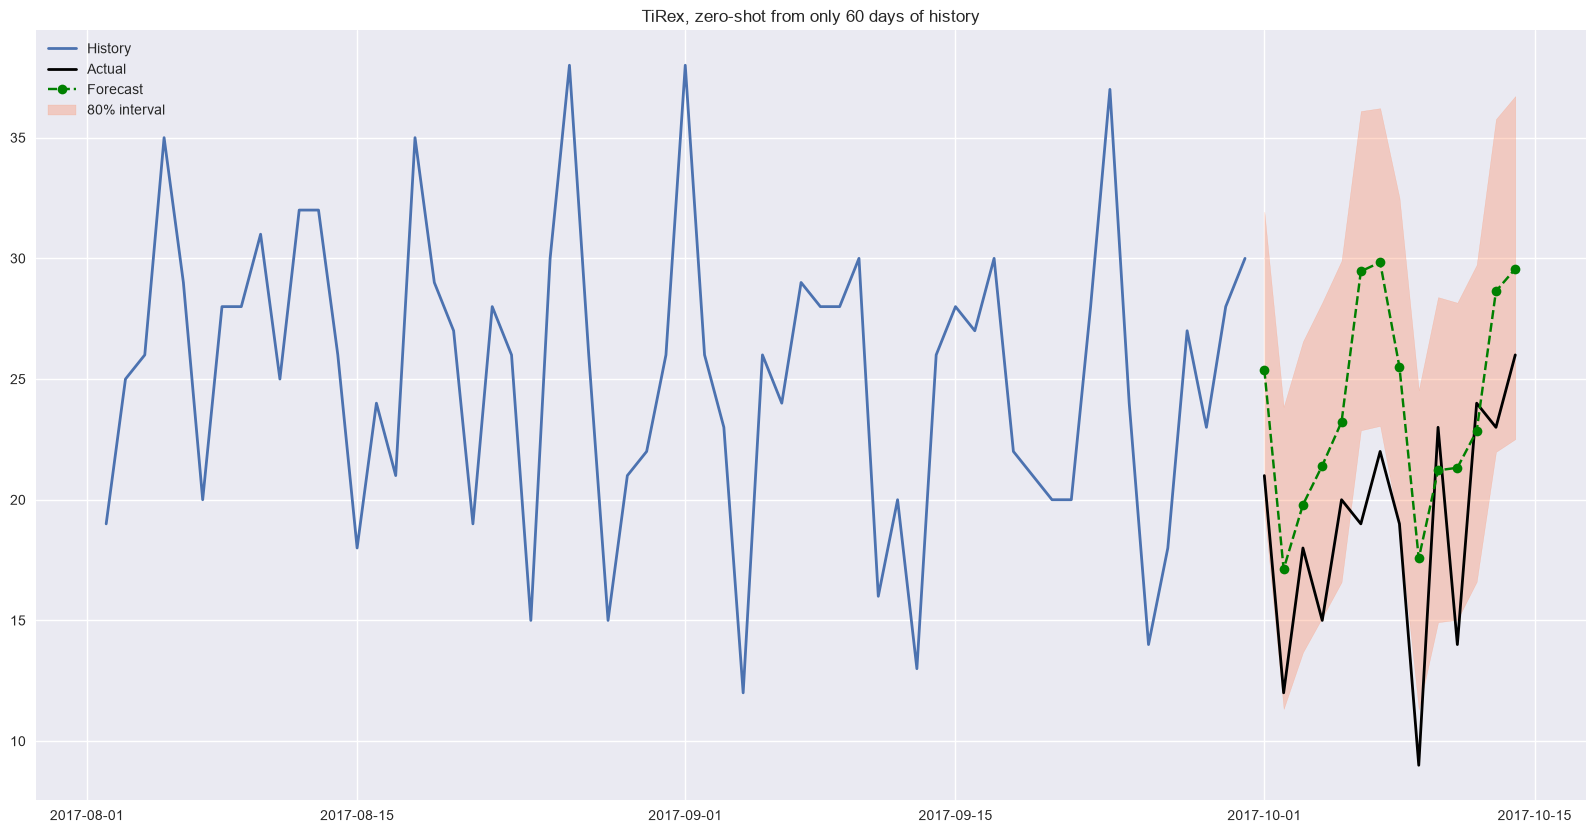

In [36]:
q_cold = tirex_q_cold[0].numpy()
plot_forecast(CFG.HERO_ITEM, origin0, tirex_m_cold[0].numpy(),
              "TiRex, zero-shot from only 60 days of history",
              lower=q_cold[:, 0], upper=q_cold[:, 8],
              history_days=COLD_DAYS)

The cold-start close-up, with everything the model was given on screen: sixty days in,
a calibrated two-week forecast out — weekly seesaw in place, level tracked, honest
uncertainty band around it. Rewind to the start of this series and consider what this
plot would have taken in episode one: identify the seasonality, difference the trend,
pick orders, fit, diagnose, iterate. Whatever reservations the next section raises,
*this* — competent forecasts on data-starved series, for free — is the genuinely new
capability foundation models brought to the table.

# The evaluation crisis

Time to spoil the party, carefully. Our arena result — three zero-shot models beating
honest local specialists — mirrors the headline claims of every foundation-model
paper. But the fine print of those claims has become its own research topic, and three
issues deserve a place in any practitioner's head.

**Data leakage.** Zero-shot means *these weights never saw this series* — but who
checks? The pre-training corpora are scraped from the same public archives (Monash,
GluonTS, Kaggle, M-competitions) that everyone benchmarks on. Our own arena is not
above suspicion: the store-item dataset is a popular Kaggle competition from 2018,
public for years before any of these models were trained. None of the three publishes
a manifest that would let us rule out its presence in their corpora. When a foundation
model aces a famous public benchmark, some of that performance may be memory, not
generalisation. The field's responses: benchmarks with enforced cutoffs (GIFT-Eval,
fev-bench), evaluation on data published *after* a model's training cutoff (the
electricity-feeder study we cited did exactly this), and — most directly —
decontaminated checkpoints like TiRex-2's `-g` and `-f` variants, retrained with the
benchmark datasets explicitly excluded. Your own private data remains the only
benchmark you can fully trust.

**The baseline problem.** A recurring, embarrassing literature finding: on stable,
low-frequency series — monthly sales with clean seasonality, say — statistical
workhorses (ETS, Theta, seasonal naive) still match or beat billion-parameter models,
at a millionth of the cost. Our arena, with its 11.55-RMSE
naive baseline soundly beaten, is favourable terrain for the big models: daily
frequency, long history, subtle trend interactions. Move to twenty-four points of
monthly data and the picture can invert. No leaderboard exempts you from running the
free baseline on *your* data first.

**Benchmarks are not deployments.** Pooled RMSE on 1,680 forecast days is a fine
scorecard and a poor business metric. The feeder study made this point sharply by
scoring peak-load errors against the physical damage curve of a grid fuse — the
forecast errors that *cost money* are not the ones RMSE emphasises. Before promoting
any model, foundation or local, translate its errors into the units your decisions
are made in.

# Where this leaves us

The season-long arc of this series has been a march of increasing machinery — and this
episode's twist is that the machinery has left the building. What we established
today, on real data and a level playing field:

1. **Zero-shot forecasting works.** Three foundation models with nothing but a 512-day
   context beat specialists trained on the very panel being forecast:
   7.74 / 8.3 / 8.76 RMSE
   versus 9.37 for the GRU and
   11.55 for seasonal naive — with near-nominal 80%
   coverage thrown in for free.
2. **The tokenization question has an answer.** Patching won; the quantization
   pioneer's own successor abandoned the vocabulary. The backbone question, by
   contrast, ended in a draw — a 35M-parameter recurrent model hangs with
   200M-parameter transformers, so pick by deployment shape, not ideology.
3. **Cold start is the killer app.** Sixty days of history was enough for zero-shot
   models to beat a fully-trained GRU; it was nowhere near enough to train anything.
4. **Skepticism is part of the toolkit.** Leakage, friendly benchmarks, and RMSE
   myopia all inflate foundation-model claims; private data and free baselines deflate
   them.

A practical routing rule to leave with, distilled from the deployment literature:
**central business forecasting** over many series with decent history — a
patch-transformer like TimesFM 2.5 or Chronos-2, with covariates when you have them;
**streaming and edge**, where memory and latency are the constraint — a recurrent
model like TiRex; **high-cardinality machine telemetry** — the observability
specialists like Toto 2.0; **no infrastructure at all** — a managed API like TimeGPT,
if your data may leave the house. And in every one of these cells: seasonal naive
first, always, because the day a fifty-year-old heuristic beats your foundation model,
you want to be the one who finds out.

Fine-tuning these models on your own panel — the middle ground between zero-shot and
from-scratch that we explored for ordinary networks in the transfer-learning episode —
is where we point the telescope next.